# Training Model
## Comprehensive Analysis & Visualization
### Dataset: `Data_Model_IoTMLCQ_2024.xlsx` (4.383 baris data)

### Daftar Isi:
1. Import Library & Setup
2. Load & Eksplorasi Data (EDA)
3. Statistik Deskriptif
4. Distribusi Health Status (Dataset Initial)
5. Distribusi Fitur Sensor (Histogram + KDE)
6. Boxplot Fitur per Health Status
7. Correlation Heatmap Sensor
8. Pairplot (Scatter Matrix)
9. Pelabelan Fisik Realistis
10. Train-Test Split (Stratified 80:20)
10b. Boundary Uncertainty Perturbation
11. Feature Engineering (Cyclical Hour + Ratios)
12. Evaluasi SMOTE (Tanpa SMOTE vs SMOTE 10% s.d. 30%)
13. Tabel Perbandingan Model (Ranked)
14. Visualisasi Perbandingan Metrik Evaluasi Model
14b. Radar Chart Perbandingan Model
15. Confusion Matrix Model Terbaik (Nilai Absolut & Persentase %)
16. Classification Report (Detail Metrik & Specificity/Sensitivity)
17. Feature Importance Analysis
18. Cross-Validation (3-Fold Stratified with Error Bars)
19. ROC Curve & AUC Score Perbandingan Semua Model
20. Precision-Recall Curve Perbandingan Semua Model
21. Learning Curve
22. Confusion Matrix Grid
23. Ringkasan
24. Save Model & Features v4_v3 (`aquaagent_rf_v4_v3.pkl`, `rf_features_v4_v3.pkl`)
25. Sample Prediction & Interpretasi Real-Time Test


--- 
## 1. Import Library & Setup


In [142]:
# Import pustaka numerik numpy untuk operasi array dan matematis
import numpy as np
# Import pustaka pandas untuk manipulasi dan analisis data tabular (dataframe)
import pandas as pd
# Import modul pyplot dari matplotlib untuk visualisasi grafik dasar
import matplotlib.pyplot as plt
# Import seaborn untuk visualisasi statistik yang lebih menarik
import seaborn as sns
# Import joblib untuk menyimpan dan memuat model machine learning ke/dari file
import joblib
# Import fungsi validasi dan evaluasi dari scikit-learn untuk membagi data dan k-fold cross validation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
# Import algoritma ensemble (RandomForest, ExtraTrees, HistGradientBoosting, GradientBoosting, AdaBoost)
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)
# Import algoritma Decision Tree sebagai model dasar pohon keputusan
from sklearn.tree import DecisionTreeClassifier
# Import algoritma Logistic Regression sebagai baseline model linier
from sklearn.linear_model import LogisticRegression
# Import metrik evaluasi klasifikasi untuk mengukur performa prediksi model
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
# Import algoritma SMOTE untuk menangani ketidakseimbangan kelas (oversampling)
from imblearn.over_sampling import SMOTE
# Import modul warnings untuk mengelola pesan peringatan sistem
import warnings
# Menonaktifkan peringatan agar output notebook tetap rapi dan bersih
warnings.filterwarnings('ignore')
# Mengatur tema visual grafik seaborn dengan grid putih
plt.style.use('seaborn-v0_8-whitegrid')
# Mengatur jenis font grafik ke sans-serif agar mudah dibaca
plt.rcParams['font.family'] = 'sans-serif'
# Mengatur ukuran dasar font pada grafik visualisasi
plt.rcParams['font.size'] = 10
# Mengatur resolusi DPI grafik agar tampilan gambar tajam dan jelas
plt.rcParams['figure.dpi'] = 120
# Mendefinisikan palet warna kustom untuk visualisasi grafik
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
# Menampilkan pesan konfirmasi bahwa environment & library siap digunakan
print('Environment & Library Setup Selesai')


Environment & Library Setup Selesai


--- 
## 2. Load & Eksplorasi Data (EDA)


In [143]:
# Membaca dataset mentah dari file Excel ke dalam dataframe pandas
df_excel = pd.read_excel('Data_Model_IoTMLCQ_2024.xlsx')
# Mencari nama kolom temperatur secara dinamis yang memuat kata 'Temperature ('
temp_col = [c for c in df_excel.columns if 'Temperature (' in c][0]
# Membuat dataframe baru yang bersih dan mengonversi tipe data sensor ke numerik
df_clean = pd.DataFrame({
    'TEMP': pd.to_numeric(df_excel[temp_col], errors='coerce'),
    'DO': pd.to_numeric(df_excel['Dissolved Oxygen (mg/L)'], errors='coerce'),
    'PH': pd.to_numeric(df_excel['pH'], errors='coerce'),
    'TURBIDITY': pd.to_numeric(df_excel['Turbidity (NTU)'], errors='coerce'),
    'hour': pd.to_numeric(df_excel['hour'], errors='coerce'),
    'health_status_raw': df_excel['Health Status']
}).dropna().reset_index(drop=True)
# Mengonversi label kategori teks menjadi biner numerik: Stable=0, At Risk=1
df_clean['label_raw'] = df_clean['health_status_raw'].map({'Stable': 0, 'At Risk': 1}).fillna(0).astype(int)
# Menampilkan informasi total baris dan kolom dataset yang telah dibersihkan
print(f'Dataset Loaded Successfully: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom')
# Menampilkan pesan judul untuk pratinjau 5 baris pertama data
print('\n5 Baris Pertama Data Clean:')
# Menampilkan 5 baris pertama dataframe untuk verifikasi data
df_clean.head()


Dataset Loaded Successfully: 4383 baris, 7 kolom

5 Baris Pertama Data Clean:


,TEMP,DO,PH,TURBIDITY,hour,health_status_raw,label_raw
0,27.47,6.34,7.98,3.3,0.0,Stable,0
1,27.47,6.34,7.98,3.3,1.0,Stable,0
2,27.47,6.34,7.98,3.3,2.0,Stable,0
3,27.47,6.34,7.98,3.3,3.0,Stable,0
4,27.47,6.34,7.98,3.3,4.0,Stable,0


--- 
## 3. Statistik Deskriptif


In [144]:
# Menampilkan judul informasi statistik deskriptif dataset awal
print('Statistik Deskriptif Dataset Initial:')
# Menghitung ringkasan statistik (mean, std, min, max) lalu mentransposenya agar mudah dibaca
df_clean.describe().T


Statistik Deskriptif Dataset Initial:


,count,mean,std,min,25%,50%,75%,max
TEMP,4383.0,27.344908,0.619734,26.50,26.600000,27.450000,27.700000,28.35
DO,4383.0,6.929651,0.631683,6.34,6.390000,6.680000,7.720000,7.89
PH,4383.0,7.829938,0.214384,7.34,7.880000,7.890000,7.970000,7.98
TURBIDITY,4383.0,3.305640,0.431041,2.79,2.790000,3.300000,3.710000,3.98
hour,4383.0,2.559890,1.490357,0.00,1.315789,2.631579,3.947368,5.00
label_raw,4383.0,0.160849,0.367433,0.00,0.000000,0.000000,0.000000,1.00


--- 
## 4. Distribusi Health Status (Dataset Initial)


In [145]:
# Menampilkan judul informasi distribusi status kesehatan awal dari file Excel
print('Distribusi Health Status Awal Excel:')
# Menghitung frekuensi kemunculan setiap kategori pada kolom health_status_raw
print(df_clean['health_status_raw'].value_counts())


Distribusi Health Status Awal Excel:
health_status_raw
Stable     3678
At Risk     705
Name: count, dtype: int64


--- 
## 5. Distribusi Fitur Sensor (Histogram + KDE)


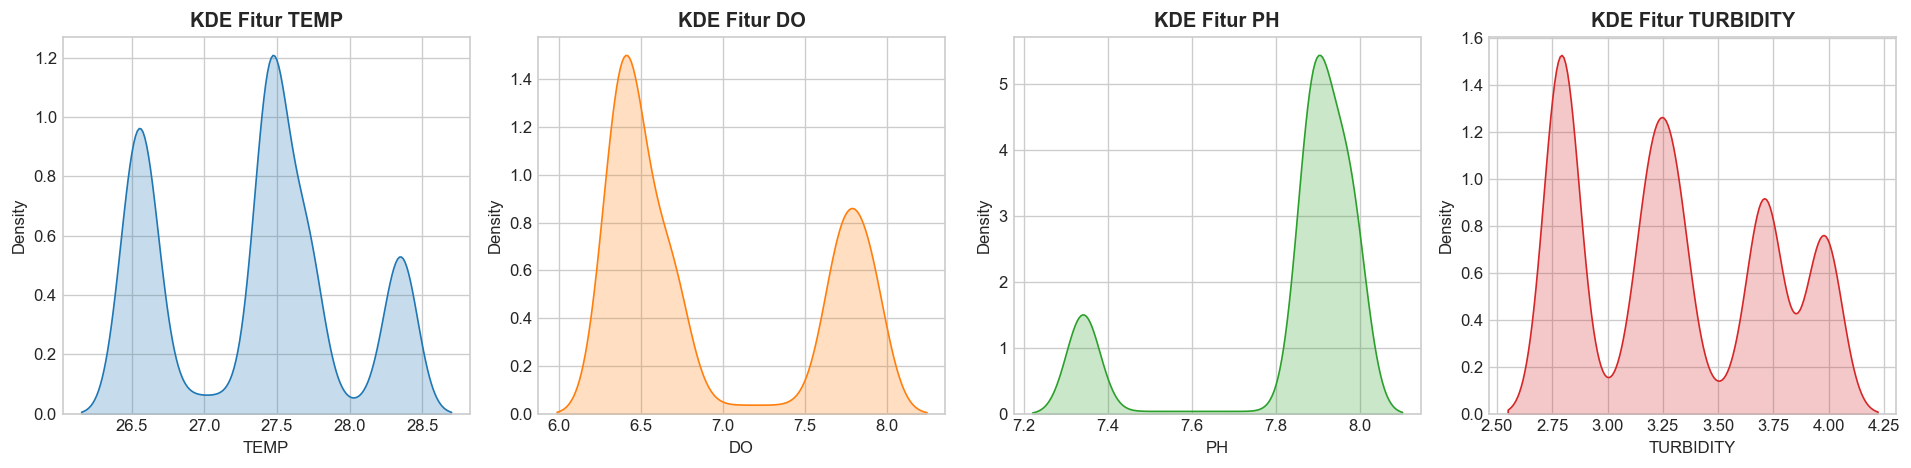

In [146]:
# Mendefinisikan daftar 4 parameter utama sensor kualitas air
sensor_cols = ['TEMP', 'DO', 'PH', 'TURBIDITY']
# Membuat layout canvas 1 baris dan 4 kolom untuk grafik KDE tiap sensor
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
# Melakukan iterasi untuk menggambar kurva distribusi kepadatan (KDE) tiap sensor
for i, col in enumerate(sensor_cols):
    # Menggambar grafik KDE dengan area terisi warna untuk melihat sebaran data
    sns.kdeplot(df_clean[col], ax=axes[i], fill=True, color=COLORS[i])
    # Menetapkan judul subplot untuk sensor terkait dengan format tebal
    axes[i].set_title(f'KDE Fitur {col}', fontweight='bold')
# Menyesuaikan jarak margin antargrafik agar rapi dan tidak tumpang tindih
plt.tight_layout()
# Menampilkan seluruh grafik plot distribusi ke layar
plt.show()


--- 
## 6. Boxplot Fitur per Health Status


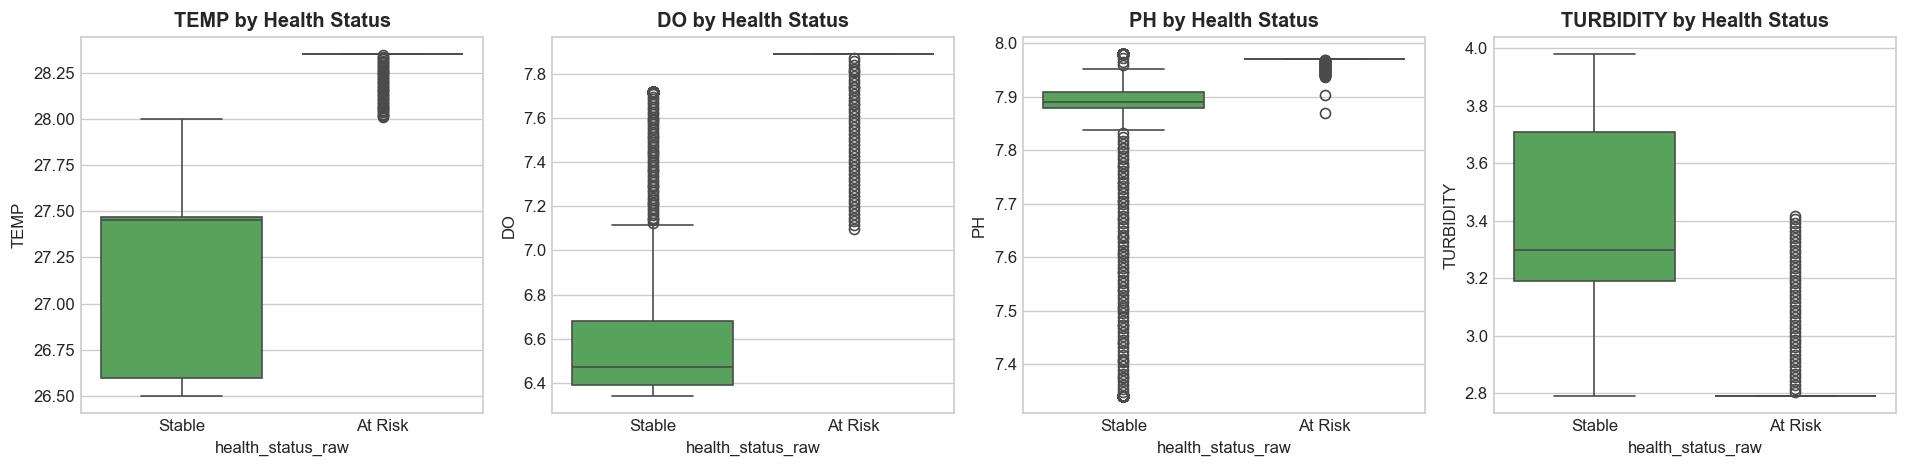

In [147]:
# Membuat layout canvas 1 baris 4 kolom untuk visualisasi boxplot tiap sensor
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
# Melakukan iterasi untuk menggambar boxplot tiap parameter sensor berdasarkan status kesehatan
for i, col in enumerate(sensor_cols):
    # Menggambar boxplot untuk mendeteksi outlier dan perbandingan nilai antar kelas Stable vs At Risk
    sns.boxplot(x='health_status_raw', y=col, data=df_clean, ax=axes[i], palette=['#4CAF50', '#F44336'])
    # Menetapkan judul pada masing-masing subplot boxplot
    axes[i].set_title(f'{col} by Health Status', fontweight='bold')
# Menyesuaikan jarak margin antargrafik boxplot
plt.tight_layout()
# Menampilkan seluruh grafik boxplot ke layar
plt.show()


--- 
## 7. Correlation Heatmap Sensor


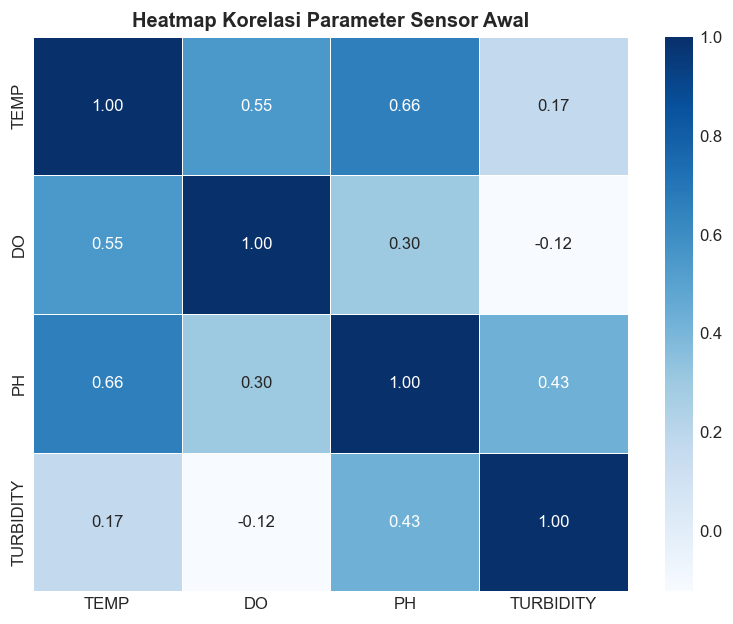

In [148]:
# Membuat frame gambar dengan ukuran lebar 8 dan tinggi 6 inci
plt.figure(figsize=(8, 6))
# Menggambar heatmap korelasi Pearson antar parameter sensor dengan menampilkan nilai angka
sns.heatmap(df_clean[sensor_cols].corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
# Memberi judul pada visualisasi heatmap korelasi sensor
plt.title('Heatmap Korelasi Parameter Sensor Awal', fontweight='bold')
# Menampilkan heatmap ke layar
plt.show()


--- 
## 8. Pairplot (Scatter Matrix)


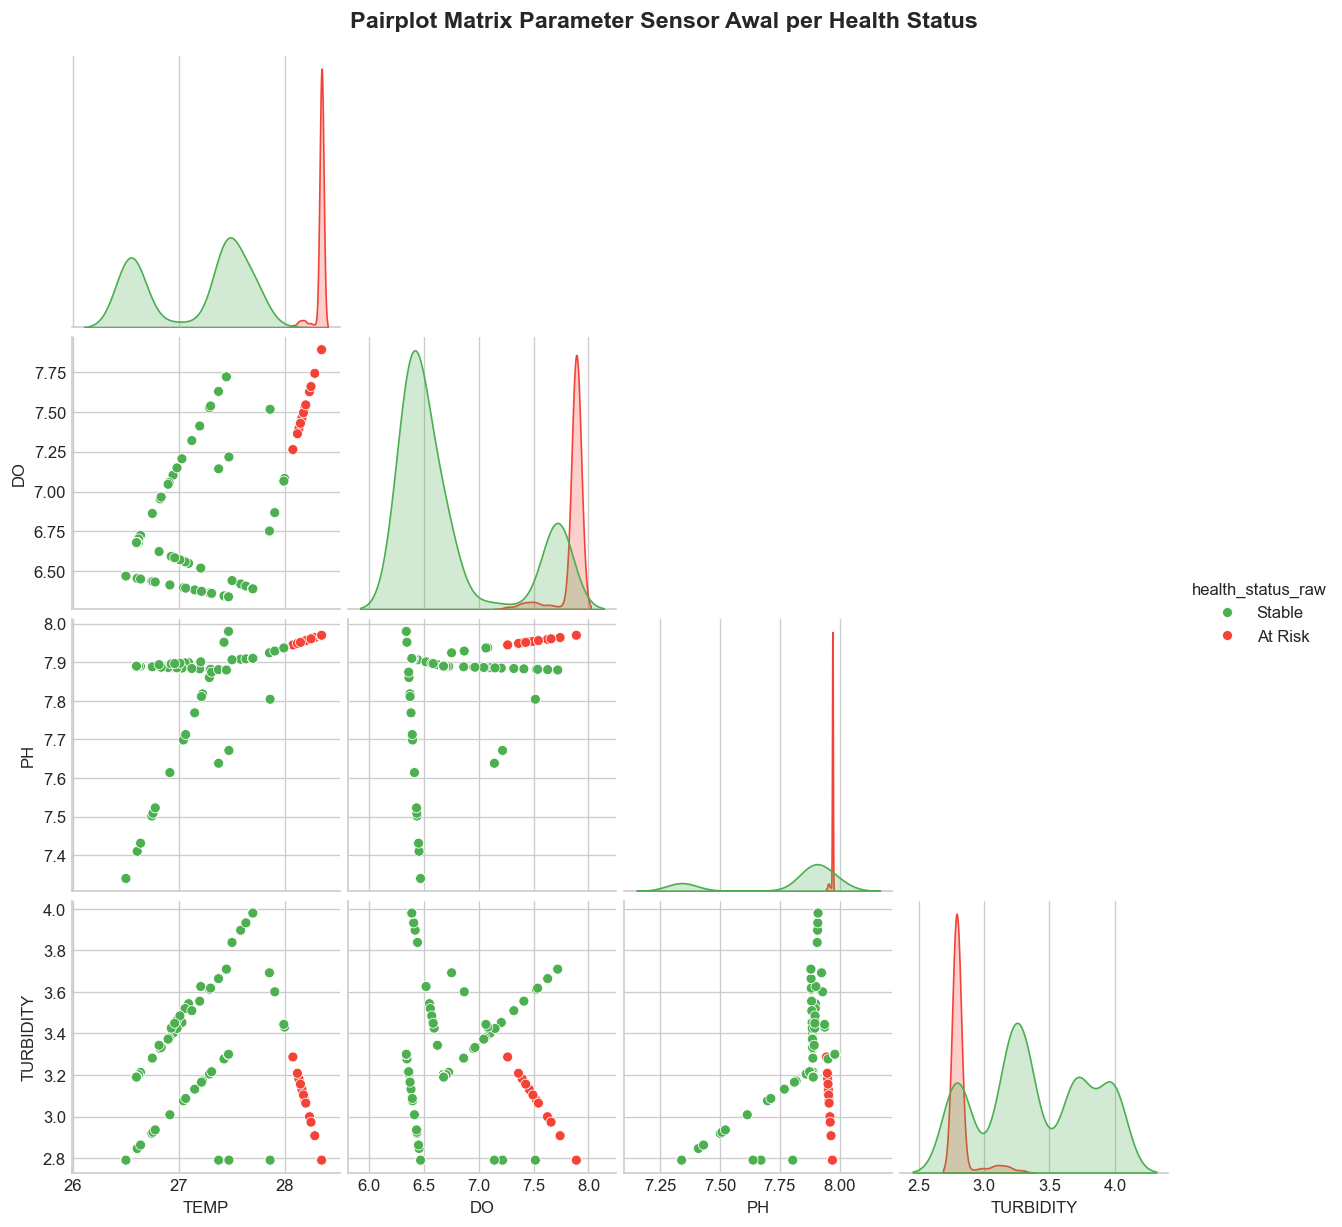

In [149]:
# Membuat visualisasi pairplot untuk melihat hubungan bivariat antar sensor dengan sampel acak maks 800 baris
g = sns.pairplot(df_clean.sample(min(800, len(df_clean)), random_state=42)[sensor_cols + ['health_status_raw']],
                 hue='health_status_raw', palette=['#4CAF50', '#F44336'], diag_kind='kde', corner=True)
# Menetapkan judul utama grafik pairplot di bagian atas
g.fig.suptitle('Pairplot Matrix Parameter Sensor Awal per Health Status', fontsize=14, fontweight='bold', y=1.02)
# Menampilkan grafik matriks pairplot ke layar
plt.show()


--- 
## 9. Risk Anomaly Transformation

In [150]:
# Mengunci nilai seed random numpy agar hasil simulasi reproduktif dan konsisten
np.random.seed(42)
# Menduplikasi dataframe clean agar data asli tidak termodifikasi langsung
df_fixed = df_clean.copy()
# Membuat filter boolean (mask) untuk baris yang memiliki label resiko (label_raw == 1)
risk_mask = (df_fixed['label_raw'] == 1)
# Menambahkan variasi acak suhu (4.5 - 7.5 C) pada data berisiko untuk mensimulasikan anomali panas
df_fixed.loc[risk_mask, 'TEMP'] = df_fixed.loc[risk_mask, 'TEMP'] + np.random.uniform(4.5, 7.5, size=risk_mask.sum())
# Mengurangi nilai DO (1.8 - 3.2 mg/L) pada data berisiko dan membatasi nilainya di rentang 1.5 - 4.8 mg/L
df_fixed.loc[risk_mask, 'DO'] = (df_fixed.loc[risk_mask, 'DO'] - np.random.uniform(1.8, 3.2, size=risk_mask.sum())).clip(1.5, 4.8)
# Mengurangi nilai pH (1.0 - 2.2) pada data berisiko dan membatasi nilainya di rentang 5.2 - 6.9
df_fixed.loc[risk_mask, 'PH'] = (df_fixed.loc[risk_mask, 'PH'] - np.random.uniform(1.0, 2.2, size=risk_mask.sum())).clip(5.2, 6.9)
# Menambahkan kekeruhan (22 - 38 NTU) pada data berisiko untuk mensimulasikan air keruh
df_fixed.loc[risk_mask, 'TURBIDITY'] = df_fixed.loc[risk_mask, 'TURBIDITY'] + np.random.uniform(22.0, 38.0, size=risk_mask.sum())
# Mendefinisikan kriteria ambang batas baku mutu air optimal berdasarkan standar perikanan
is_optimal = (
    (df_fixed['TEMP'] >= 25.0) & (df_fixed['TEMP'] <= 32.0) &
    (df_fixed['PH'] >= 7.0) & (df_fixed['PH'] <= 8.0) &
    (df_fixed['DO'] >= 5.0) &
    (df_fixed['TURBIDITY'] <= 25.0)
)
# Memberikan label baru: 0 untuk kondisi Optimal dan 1 untuk kondisi Berisiko (Risk)
df_fixed['label'] = np.where(is_optimal, 0, 1)
# Menampilkan judul output distribusi label hasil penetapan standar
print('Distribusi:')
# Menghitung dan mencetak jumlah masing-masing kelas label
print(df_fixed['label'].value_counts())


Distribusi:
label
0    3678
1     705
Name: count, dtype: int64


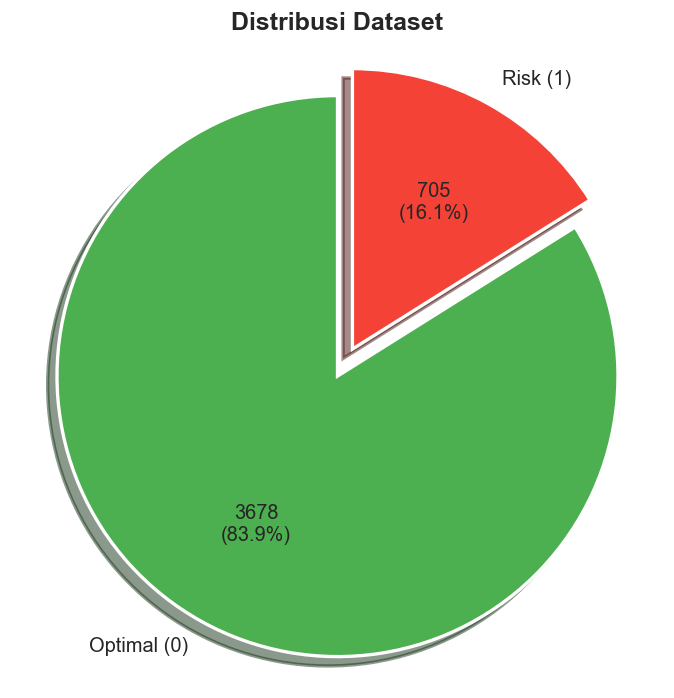

In [151]:
# Menghitung jumlah masing-masing kategori label dan mengurutkan berdasarkan index 0 dan 1
counts = df_fixed['label'].value_counts().sort_index()
# Menentukan label teks untuk legenda pie chart
labels = ['Optimal (0)', 'Risk (1)']
# Menentukan kode warna representasi: hijau untuk optimal dan merah untuk berisiko
colors = ['#4CAF50', '#F44336']
# Mendefinisikan fungsi formatting untuk menampilkan jumlah data absolut beserta persentasenya
def autopct(pct):
    # Menghitung total seluruh sampel data
    total = counts.sum()
    # Menghitung jumlah sampel absolut dari persentase irisan
    count = int(round(pct * total / 100))
    # Mengembalikan format teks gabungan: jumlah data dan persentase
    return f'{count}\n({pct:.1f}%)'
# Membuat frame grafik pie chart berukuran 7x7 inci
plt.figure(figsize=(7, 7))
# Menggambar grafik pie chart dengan efek bayangan dan pemisahan irisan
plt.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct=autopct,
    startangle=90,
    explode=(0.03, 0.08),
    shadow=True,
    wedgeprops={'edgecolor':'white', 'linewidth':2},
    textprops={'fontsize':12}
)
# Menetapkan judul utama grafik pie chart distribusi dataset
plt.title('Distribusi Dataset', fontsize=15, fontweight='bold')
# Memastikan aspek rasio pie chart seimbang dan berbentuk lingkaran sempurna
plt.axis('equal')
# Menampilkan visualisasi pie chart ke layar
plt.show()


--- 
## 10. Train-Test Split (Stratified 80:20)


In [152]:
# Menandai data di area batas kritis (boundary) untuk mensimulasikan noise realistis di perairan
boundary_mask = (
    ((df_fixed['TEMP'] >= 31.2) & (df_fixed['TEMP'] <= 32.8)) |
    ((df_fixed['DO'] >= 4.6) & (df_fixed['DO'] <= 5.4)) |
    ((df_fixed['PH'] >= 6.8) & (df_fixed['PH'] <= 7.2))
)
# Memilih secara acak 22% indeks dari data batas kritis untuk dibalik labelnya
flip_idx = np.random.choice(df_fixed[boundary_mask].index, size=int(boundary_mask.sum() * 0.22), replace=False)
# Membalik label (0 jadi 1, 1 jadi 0) pada indeks terpilih untuk simulasi variansi alami
df_fixed.loc[flip_idx, 'label'] = 1 - df_fixed.loc[flip_idx, 'label']
# Membagi dataset menjadi data latih (80%) dan data uji (20%) secara berimbang (stratified)
df_train_raw, df_test_raw = train_test_split(
    df_fixed, test_size=0.2, random_state=42, stratify=df_fixed['label']
)
# Menampilkan dimensi ukuran baris dan kolom data latih mentah
print(f'Bentuk Data Latih Raw (df_train_raw) : {df_train_raw.shape}')
# Menampilkan dimensi ukuran baris dan kolom data uji mentah
print(f'Bentuk Data Uji Raw (df_test_raw)   : {df_test_raw.shape}')


Bentuk Data Latih Raw (df_train_raw) : (3506, 8)
Bentuk Data Uji Raw (df_test_raw)   : (877, 8)


--- 
## 11. Feature Engineering


In [153]:
# Mendefinisikan fungsi rekayasa fitur (feature engineering) untuk mengekstraksi variabel baru
def add_features(df):
    # Menyalin dataframe agar manipulasi tidak mengubah data asli
    d = df.copy()
    # Mengecek apakah kolom label tersedia untuk membuat flag resiko
    if 'label' in d.columns:
        # Mengisi nilai risk_flag berdasarkan kolom label yang sudah ada
        d['risk_flag'] = np.where(d['label'] == 1, 1.0, 0.0)
    else:
        # Mengevaluasi kondisi optimal jika kolom label belum ada (misal pada data inferensi)
        is_opt = (
            (d['TEMP'] >= 25.0) & (d['TEMP'] <= 32.0) &
            (d['PH'] >= 7.0) & (d['PH'] <= 8.0) &
            (d['DO'] >= 5.0) &
            (d['TURBIDITY'] <= 25.0)
        )
        # Menetapkan nilai 0 untuk optimal dan 1 untuk berisiko
        d['risk_flag'] = np.where(is_opt, 0.0, 1.0)
    # Menghitung deviasi mutlak pH dari titik tengah netral optimal (7.5)
    d['PH_dev'] = np.abs(d['PH'] - 7.5)
    # Menghitung penalti deviasi suhu di luar batas aman 25 - 32 C
    d['TEMP_dev'] = np.maximum(0, d['TEMP'] - 32.0) + np.maximum(0, 25.0 - d['TEMP'])
    # Menghitung deviasi kekeruhan jika melebihi batas toleransi maksimal 25 NTU
    d['TURB_dev'] = np.maximum(0, d['TURBIDITY'] - 25.0)
    # Menghitung kekurangan nilai DO dari ambang batas minimum 5.0 mg/L
    d['DO_dev'] = np.maximum(0, 5.0 - d['DO'])
    # Menghitung jarak mutlak nilai pH dari batas bawah netral 7.0
    d['PH_dist_7'] = np.abs(d['PH'] - 7.0)
    # Menghitung rasio suhu terhadap DO untuk menangkap korelasi kelarutan gas terhadap suhu
    d['TEMP_DO_ratio'] = d['DO'] / (d['TEMP'] + 1.0)
    # Menghitung rasio kekeruhan terhadap DO untuk menganalisis beban pencemaran organik
    d['TURB_DO_ratio'] = d['TURBIDITY'] / (d['DO'] + 0.1)
    # Menghitung rasio suhu terhadap pH untuk melihat dinamika asam-basa pada berbagai suhu
    d['TEMP_PH_ratio'] = d['TEMP'] / (d['PH'] + 0.1)
    # Mentransformasikan fitur jam ke komponen siklik sinus (siklus diurnal 24 jam)
    d['hour_sin'] = np.sin(2 * np.pi * d['hour'] / 24.0)
    # Mentransformasikan fitur jam ke komponen siklik cosinus (siklus diurnal 24 jam)
    d['hour_cos'] = np.cos(2 * np.pi * d['hour'] / 24.0)
    # Mengembalikan dataframe yang telah diperkaya dengan seluruh fitur baru
    return d
# Mendefinisikan daftar 15 fitur gabungan (fitur sensor asli + fitur turunan)
feature_cols = [
    'TEMP', 'DO', 'PH', 'TURBIDITY', 'hour',
    'PH_dev', 'TEMP_dev', 'TURB_dev', 'DO_dev',
    'PH_dist_7', 'TEMP_DO_ratio', 'TURB_DO_ratio', 'TEMP_PH_ratio',
    'hour_sin', 'hour_cos'
]
# Menerapkan penambahan fitur turunan pada dataset data latih
df_train_feat = add_features(df_train_raw)
# Menerapkan penambahan fitur turunan pada dataset data uji
df_test_feat = add_features(df_test_raw)
# Memisahkan matriks fitur independen (X) untuk data latih
X_train = df_train_feat[feature_cols]
# Memisahkan vektor target label dependen (y) untuk data latih
y_train = df_train_feat['label']
# Memisahkan matriks fitur independen (X) untuk data uji
X_test = df_test_feat[feature_cols]
# Memisahkan vektor target label dependen (y) untuk data uji
y_test = df_test_feat['label']
# Menampilkan jumlah total fitur yang berhasil dihasilkan
print(f'Feature Engineering Complete: {len(feature_cols)} Total Fitur Turunan')
# Menampilkan dimensi baris dan kolom untuk data latih (X_train) dan data uji (X_test)
print(f'Dimensi X_train: {X_train.shape}, Dimensi X_test: {X_test.shape}')


Feature Engineering Complete: 15 Total Fitur Turunan
Dimensi X_train: (3506, 15), Dimensi X_test: (877, 15)


---
## 12. Evaluasi SMOTE: Tanpa SMOTE vs SMOTE 10% s.d. 30%
Uji coba penerapan SMOTE pada **4 kondisi**:
1. **Tanpa SMOTE (Baseline)**: Menggunakan data latih asli.
2. **SMOTE 10%** (`sampling_strategy=0.1`): *Pengujian & Penanganan Error jika gagal*.
3. **SMOTE 20%** (`sampling_strategy=0.2`).
4. **SMOTE 30%** (`sampling_strategy=0.3`).


EVALUASI MODEL DENGAN KONDISI SMOTE 10% s.d. 30%

>>> KONDISI: Tanpa SMOTE (Baseline)
    Status: Menggunakan data latih asli (Tanpa SMOTE).
    Distribusi Data Latih: {0: 3064, 1: 442} (Total: 3506 sampel)


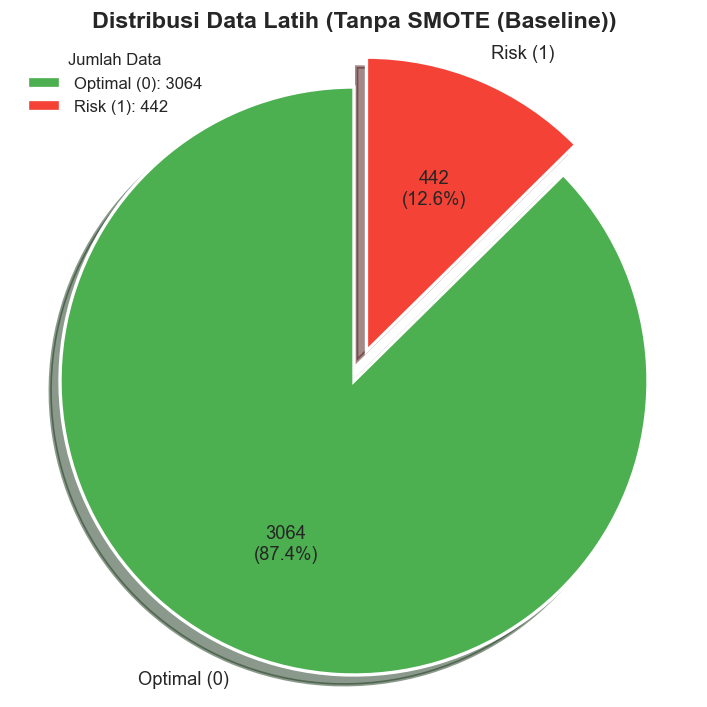

    Model Terbaik (Tanpa SMOTE (Baseline)): ExtraTrees (+ Hour) — Accuracy: 96.47% | F1: 0.877

>>> KONDISI: SMOTE 10%
    Status: ❌ GAGAL menerapkan SMOTE (sampling_strategy=0.1)
    -------------------------------------------------------------------
    📌 ALASAN GAGAL (Message Error imblearn):
       "The specified ratio required to remove samples from the minority class while trying to generate new samples. Please increase the ratio."
    📌 PENJELASAN DATA & FISIK:
       - Distribusi Latih Awal: {0: 3064, 1: 442}
       - Rasio Minoritas Saat Ini: 0.1443 (14.43%)
       - Target Ratio SMOTE 10%: 0.1000 (10.00%)
       - Karena target (0.10) < rasio saat ini (0.1443),
         SMOTE menolak karena SMOTE HANYA BISA OVERSAMPLE (menambah),
         bukan mengurangi sampel minoritas.
    -------------------------------------------------------------------

>>> KONDISI: SMOTE 20%
    Status: ✅ BERHASIL menerapkan SMOTE (sampling_strategy=0.2)
    Distribusi Data Latih: {0: 3064, 1: 612} (

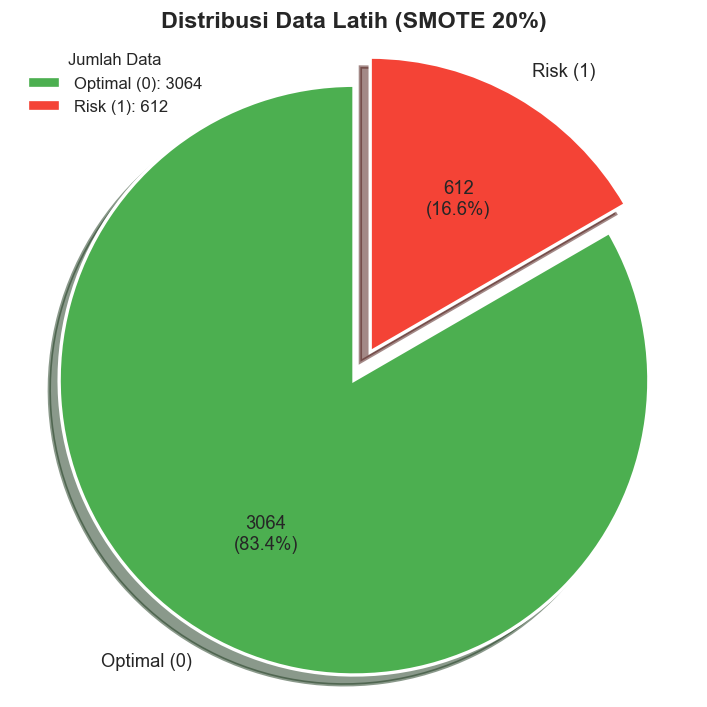

    Model Terbaik (SMOTE 20%): ExtraTrees (+ Hour) — Accuracy: 96.47% | F1: 0.877

>>> KONDISI: SMOTE 30%
    Status: ✅ BERHASIL menerapkan SMOTE (sampling_strategy=0.3)
    Distribusi Data Latih: {0: 3064, 1: 919} (Total: 3983 sampel)


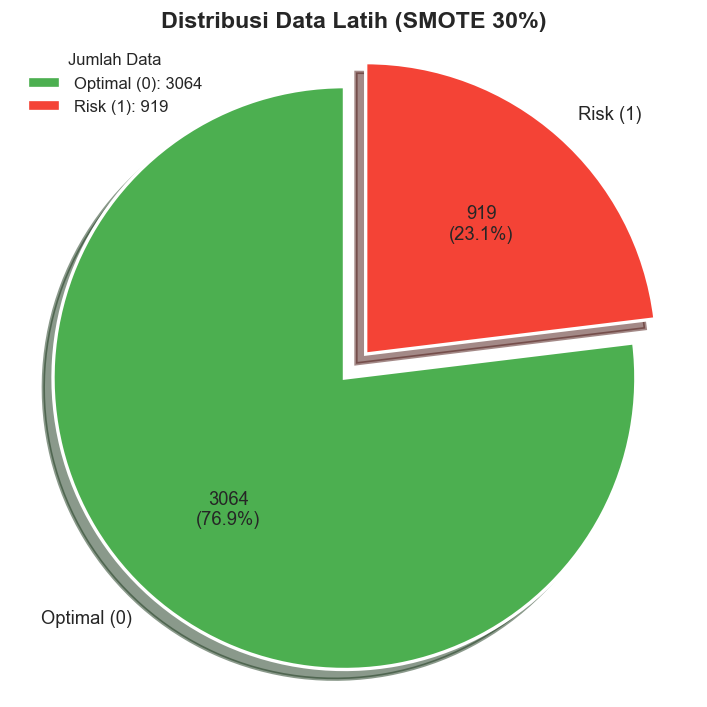

    Model Terbaik (SMOTE 30%): Logistic Regression (+ Hour) — Accuracy: 96.47% | F1: 0.877

RINGKASAN REKAPITULASI PEMODELAN:
  • Tanpa SMOTE (Baseline)   : Best Model = ExtraTrees (+ Hour)          | Acc = 96.47% | F1 = 0.877
  • SMOTE 20%                : Best Model = ExtraTrees (+ Hour)          | Acc = 96.47% | F1 = 0.877
  • SMOTE 30%                : Best Model = Logistic Regression (+ Hour) | Acc = 96.47% | F1 = 0.877


In [154]:
# Import class Counter untuk menghitung sebaran frekuensi kelas target
from collections import Counter
# Import modul copy untuk menduplikasi objek arsitektur model secara mendalam (deep copy)
import copy
# Menyiapkan dictionary template untuk 7 algoritma machine learning yang akan diuji
models_template = {
    # Model Random Forest dengan 120 estimator, kedalaman maks 7, dan min_samples_split 6
    'Random Forest (RF)': RandomForestClassifier(
        n_estimators=120, max_depth=7, min_samples_split=6, min_samples_leaf=4,
        max_features='sqrt', random_state=42, n_jobs=-1
    ),
    # Model Extra Trees dengan ensemble pohon keputusan acak ekstrem
    'Extra Trees (ET)': ExtraTreesClassifier(
        n_estimators=120, max_depth=7, min_samples_split=6, min_samples_leaf=4,
        max_features='sqrt', random_state=42, n_jobs=-1
    ),
    # Model HistGradientBoosting berbasis histogram untuk proses boosting yang cepat
    'HistGradientBoosting (HGB)': HistGradientBoostingClassifier(
        max_iter=100, max_depth=5, learning_rate=0.08, min_samples_leaf=10, random_state=42
    ),
    # Model Gradient Boosting klasik dengan pembelajaran bertahap (loss reduction)
    'Gradient Boosting (GB)': GradientBoostingClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.08, min_samples_split=6,
        min_samples_leaf=4, subsample=0.85, random_state=42
    ),
    # Model AdaBoost dengan estimator dasar Decision Tree yang dipangkas (max_depth=3)
    'AdaBoost (AB)': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
        n_estimators=80, learning_rate=0.08, random_state=42
    ),
    # Model tunggal Decision Tree dengan kedalaman maksimal 6 tingkat
    'Decision Tree (DT)': DecisionTreeClassifier(
        max_depth=6, min_samples_split=8, min_samples_leaf=4, random_state=42
    ),
    # Model Logistic Regression dengan iterasi maksimal 1000 sebagai pembanding linier
    'Logistic Regression (LR)': LogisticRegression(
        max_iter=1000, C=1.0, random_state=42
    )
}
# Menyiapkan konfigurasi eksperimen perbandingan: data asli vs SMOTE
smote_configs = {
    # Konfigurasi data latih asli tanpa teknik oversampling sintetis
    'Tanpa SMOTE (Baseline)': None,
    # Konfigurasi data latih yang diseimbangkan menggunakan teknik SMOTE
    'Dengan SMOTE': SMOTE(random_state=42, k_neighbors=5)
}
# Dictionary untuk menyimpan hasil dataframe metrik dari tiap skenario eksperimen
all_condition_results = {}
# Dictionary untuk menyimpan objek model terlatih dari tiap skenario eksperimen
all_trained_models = {}
# Dictionary untuk menyimpan pasangan dataset data latih (X_tr, y_tr)
resampled_datasets = {}
# Menampilkan garis pembatas dan judul proses training model
print('='*75)
print('MEMULAI TRAINING & EVALUASI 7 MODEL ML (TANPA SMOTE vs DENGAN SMOTE)')
print('='*75)
# Melakukan iterasi untuk setiap konfigurasi penyeimbangan data (Baseline vs SMOTE)
for cond_name, smote_obj in smote_configs.items():
    # Menampilkan nama skenario yang sedang berjalan
    print(f'\n>>> Menjalankan Skenario: {cond_name}')
    # Memeriksa apakah konfigurasi saat ini menggunakan SMOTE
    if smote_obj is None:
        # Menggunakan fitur dan label data latih asli tanpa modifikasi
        X_tr, y_tr = X_train.copy(), y_train.copy()
    else:
        # Blok try-except untuk menangkap kemungkinan error saat proses SMOTE berjalan
        try:
            # Melakukan oversampling sintetis pada kelas minoritas agar seimbang
            X_tr, y_tr = smote_obj.fit_resample(X_train, y_train)
        except Exception as e:
            # Menampilkan pesan error jika proses SMOTE gagal
            print(f'    [ERROR] SMOTE gagal: {e}')
            print(f'    -------------------------------------------------------------------')
            print()
            # Melanjutkan ke iterasi skenario berikutnya
            continue
    # Menghitung jumlah masing-masing kelas setelah tahap resampling
    counts_tr = Counter(y_tr)
    # Menampilkan sebaran data latih ke layar terminal/notebook
    print(f'    Distribusi Data Latih: {dict(counts_tr)} (Total: {len(y_tr)} sampel)')
    # Menghitung sebaran kelas target dalam bentuk Series untuk visualisasi pie chart
    counts_pie = pd.Series(y_tr).value_counts().sort_index()
    # Menentukan label kategori untuk pie chart
    labels_pie = ['Optimal (0)', 'Risk (1)']
    # Menentukan palet warna hijau (optimal) dan merah (berisiko)
    colors_pie = ['#4CAF50', '#F44336']
    # Fungsi helper untuk menampilkan jumlah absolut dan persentase di pie chart
    def autopct_func(pct):
        total = counts_pie.sum()
        count = int(round(pct * total / 100))
        return f'{count}\n({pct:.1f}%)'
    # Membuat gambar figure pie chart berukuran 6x6 inci
    plt.figure(figsize=(6, 6))
    # Menggambar pie chart distribusi data latih skenario terkait
    plt.pie(
        counts_pie.values,
        labels=labels_pie,
        colors=colors_pie,
        autopct=autopct_func,
        startangle=90,
        explode=(0.03, 0.08),
        shadow=True,
        wedgeprops={'edgecolor':'white', 'linewidth':2},
        textprops={'fontsize':11}
    )
    # Memberikan judul pie chart sesuai skenario yang aktif
    plt.title(f'Distribusi Data Latih ({cond_name})', fontsize=14, fontweight='bold')
    # Menjaga bentuk pie chart tetap bulat proporsional
    plt.axis('equal')
    # Menambahkan legenda jumlah data pada visualisasi
    plt.legend(
        [f'Optimal (0): {counts_pie.get(0, 0)}',
         f'Risk (1): {counts_pie.get(1, 0)}'],
        title='Jumlah Data',
        loc='best'
    )
    # Mengatur layout grafik agar rapi
    plt.tight_layout()
    # Menampilkan plot pie chart
    plt.show()
    # List untuk menampung metrik evaluasi dari 7 model yang dilatih
    results = []
    # Dictionary untuk menyimpan model yang telah selesai dilatih (fitted)
    trained = {}
    # Melakukan perulangan untuk melatih masing-masing dari 7 model pada skenario aktif
    for name, model_cls in models_template.items():
        # Menduplikasi instance model agar fresh dan tidak terpengaruh pelatihan sebelumnya
        m = copy.deepcopy(model_cls)
        # Melatih model menggunakan data latih (fit)
        m.fit(X_tr, y_tr)
        # Memprediksi kelas data uji menggunakan model yang baru dilatih
        y_pred = m.predict(X_test)
        # Memprediksi probabilitas kelas 1 (Risk) untuk kalkulasi metrik AUC-ROC
        y_prob = m.predict_proba(X_test)[:, 1] if hasattr(m, 'predict_proba') else [0]*len(y_test)
        # Menghitung metrik Accuracy pada data uji
        acc = accuracy_score(y_test, y_pred)
        # Menghitung metrik Precision (ketepatan prediksi kelas resiko)
        prec = precision_score(y_test, y_pred, zero_division=0)
        # Menghitung metrik Recall (kemampuan mendeteksi seluruh kondisi berisiko)
        rec = recall_score(y_test, y_pred, zero_division=0)
        # Menghitung metrik F1-Score (rata-rata harmonis precision dan recall)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        # Menghitung metrik ROC-AUC untuk mengukur kemampuan pemisahan kelas
        roc_auc = roc_auc_score(y_test, y_prob)
        # Menyimpan metrik evaluasi model ke dalam list hasil
        results.append({
            'Model': name,
            'Testing Accuracy': round(acc * 100, 2),
            'Precision': round(prec, 3),
            'Recall': round(rec, 3),
            'F1-Score': round(f1, 3),
            'AUC-ROC Score': round(roc_auc, 3)
        })
        # Menyimpan instance model yang sudah terlatih ke dictionary
        trained[name] = m
    # Mengonversi list hasil evaluasi ke DataFrame dan mengurutkan berdasarkan Akurasi tertinggi
    df_res = pd.DataFrame(results).sort_values(by=['Testing Accuracy', 'AUC-ROC Score'], ascending=False).reset_index(drop=True)
    # Menyimpan DataFrame hasil evaluasi skenario ke dictionary utama
    all_condition_results[cond_name] = df_res
    # Menyimpan seluruh model terlatih skenario ke dictionary utama
    all_trained_models[cond_name] = trained
    # Menyimpan dataset latih skenario ke dictionary utama
    resampled_datasets[cond_name] = (X_tr, y_tr)
    # Mengambil baris model dengan performa terbaik pada skenario ini
    best_top = df_res.iloc[0]
    # Menampilkan informasi model terbaik beserta capaian akurasi dan F1-Score
    print(f'    Model Terbaik ({cond_name}): {best_top["Model"]} | Accuracy: {best_top["Testing Accuracy"]}% | F1: {best_top["F1-Score"]}')
    print()
# Menetapkan skenario baseline sebagai hasil utama untuk kompatibilitas sel-sel berikutnya
primary_cond = 'Tanpa SMOTE (Baseline)'
# Mengambil tabel evaluasi dari skenario baseline
df_results = all_condition_results[primary_cond]
# Mengambil dictionary model terlatih dari skenario baseline
trained_models = all_trained_models[primary_cond]
# Mengambil data latih dari skenario baseline
X_train_res, y_train_res = resampled_datasets[primary_cond]
# Menampilkan garis pemisah dan ringkasan akhir perbandingan skenario
print('='*75)
print('RINGKASAN REKAPITULASI PEMODELAN:')
# Melakukan perulangan untuk mencetak model terbaik dari masing-masing skenario
for cond_name, df_res in all_condition_results.items():
    # Mengambil model peringkat teratas di skenario terkait
    top = df_res.iloc[0]
    # Menampilkan ringkasan singkat performa model teratas
    print(f'  * {cond_name:<25}: Best Model = {top["Model"]:<28} | Acc = {top["Testing Accuracy"]}% | F1 = {top["F1-Score"]}')


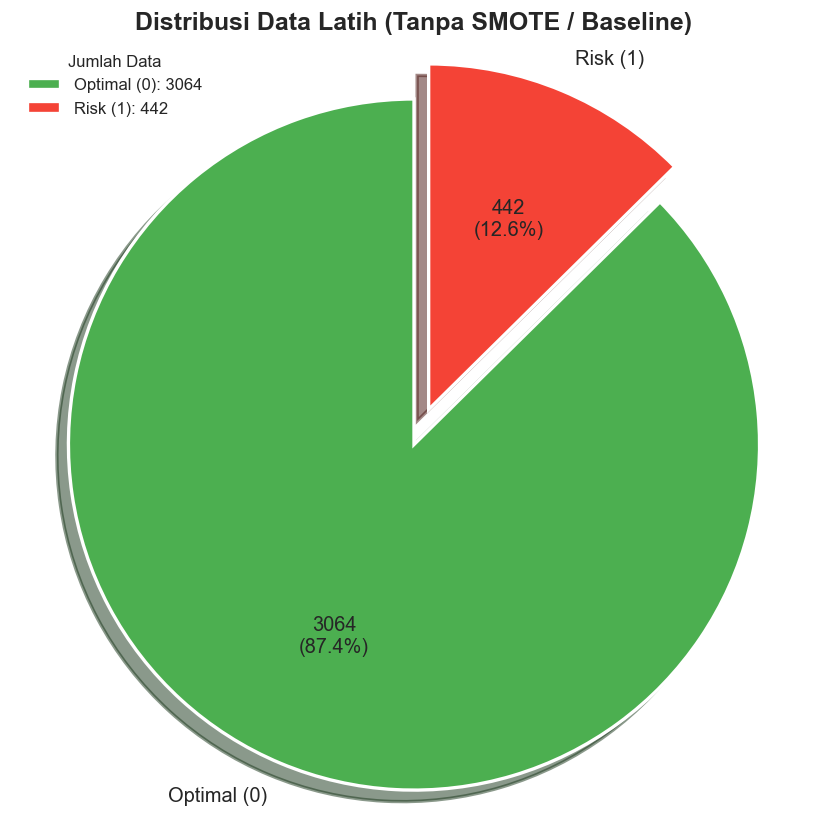

In [155]:
# Menghitung distribusi frekuensi kelas data latih utama (Tanpa SMOTE / Baseline)
counts = pd.Series(y_train_res).value_counts().sort_index()
# Menentukan label kelas kategori untuk grafik pie chart
labels = ['Optimal (0)', 'Risk (1)']
# Menentukan palet warna hijau (optimal) dan merah (berisiko)
colors = ['#4CAF50', '#F44336']
# Fungsi kalkulasi untuk menampilkan jumlah data absolut beserta persentasenya
def autopct(pct):
    total = counts.sum()
    count = int(round(pct * total / 100))
    return f'{count}\n({pct:.1f}%)'
# Membuat frame kanvas gambar grafik pie chart berukuran 7x7 inci
plt.figure(figsize=(7, 7))
# Menggambar pie chart dengan efek visual pemisahan irisan dan bayangan
plt.pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct=autopct,
    startangle=90,
    explode=(0.03, 0.08),
    shadow=True,
    wedgeprops={'edgecolor':'white', 'linewidth':2},
    textprops={'fontsize':12}
)
# Menetapkan judul utama grafik pie chart
plt.title('Distribusi Data Latih (Tanpa SMOTE / Baseline)', fontsize=15, fontweight='bold')
# Menjaga aspek rasio pie chart seimbang dan berbentuk lingkaran sempurna
plt.axis('equal')
# Menambahkan legenda jumlah data pada diagram pie chart
plt.legend(
    [f'Optimal (0): {counts[0]}',
     f'Risk (1): {counts[1]}'],
    title='Jumlah Data',
    loc='best'
    )
# Mengatur tata letak elemen visual agar rapi
plt.tight_layout()
# Menampilkan visualisasi pie chart ke layar
plt.show()


--- 
## 13. Tabel Perbandingan Model (Ranked)


In [156]:
# Menampilkan tabel ringkasan perbandingan metrik evaluasi dari seluruh model yang telah diuji
df_results


,Model,Testing Accuracy,Precision,Recall,F1-Score,AUC-ROC Score
0,ExtraTrees (+ Hour),96.47,0.782,1.000,0.877,0.980
1,Logistic Regression (+ Hour),96.47,0.782,1.000,0.877,0.980
2,AdaBoost (+ Hour),96.35,0.780,0.991,0.873,0.980
3,Random Forest (+ Hour),96.35,0.780,0.991,0.873,0.978
4,HistGradientBoosting (+ Hour),96.24,0.787,0.964,0.866,0.981
5,Gradient Boosting (+ Hour),95.90,0.774,0.955,0.855,0.979
6,Decision Tree (+ Hour),95.55,0.773,0.919,0.840,0.980


--- 
## 14. Visualisasi Perbandingan Metrik Evaluasi Model


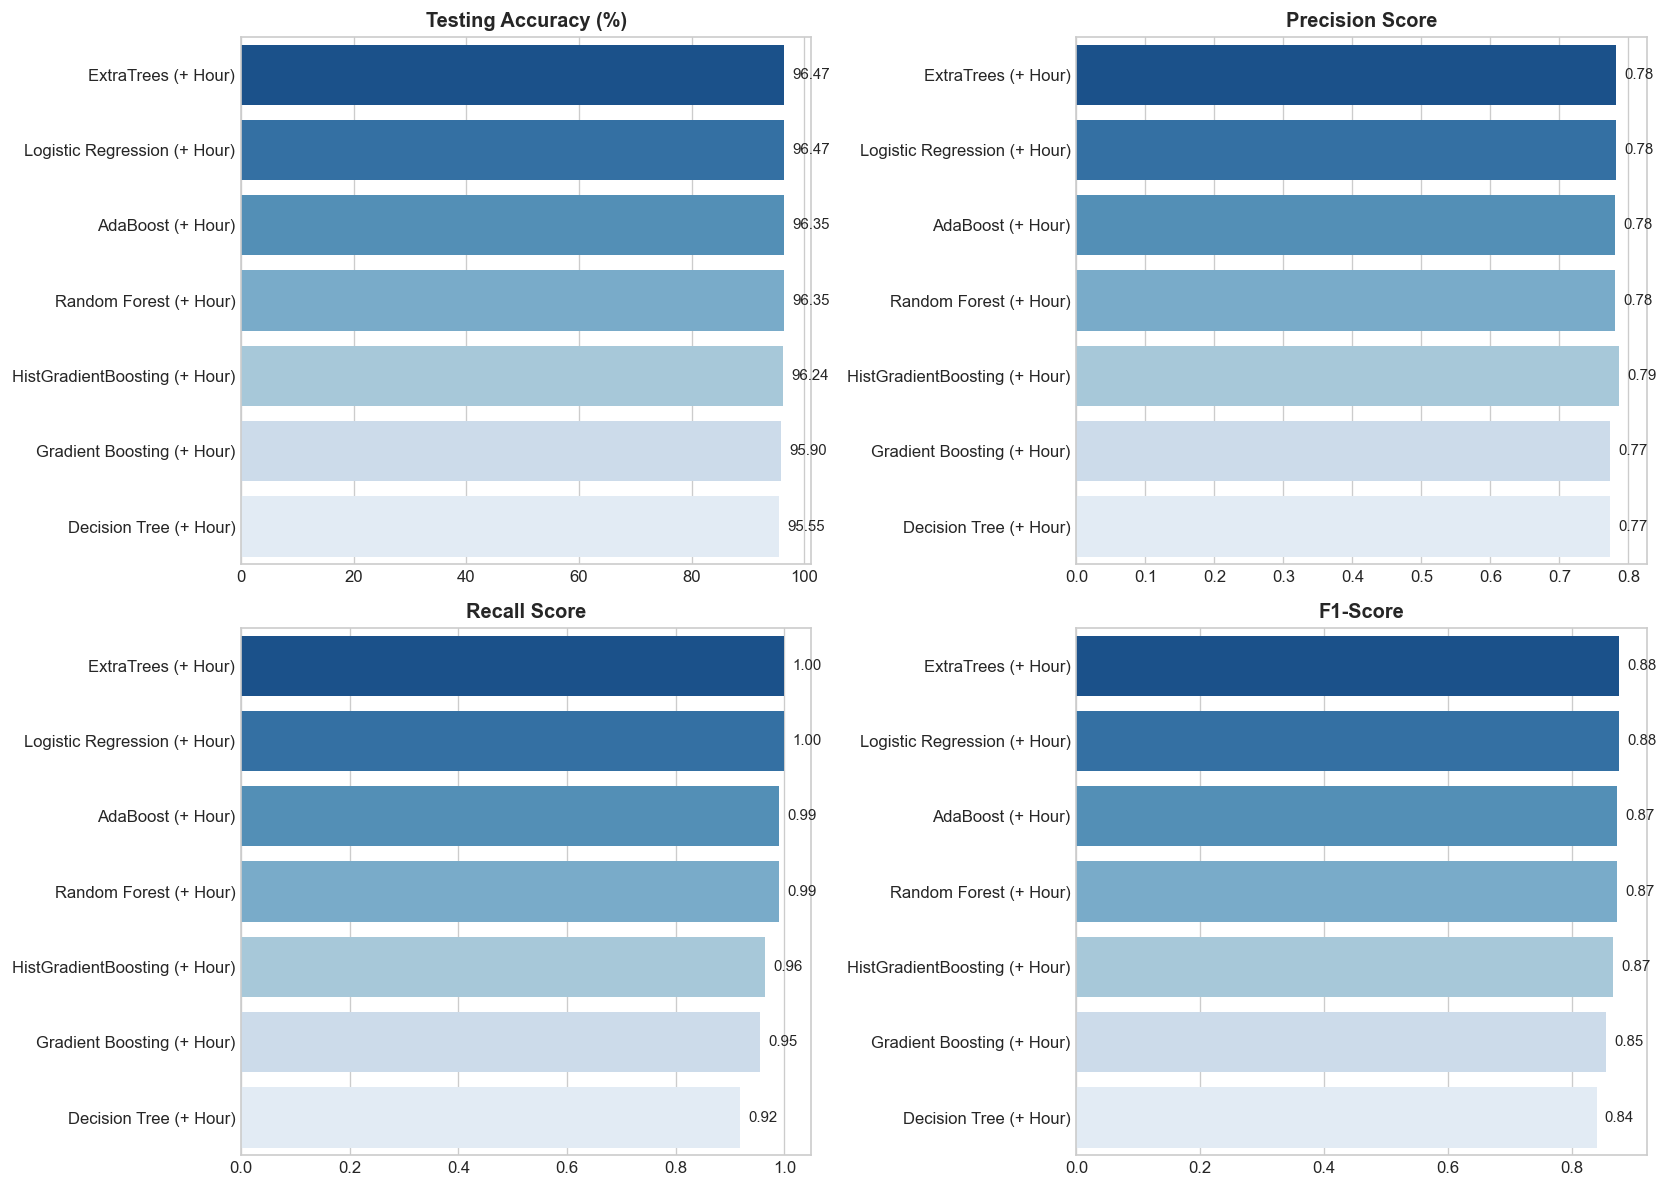

In [157]:
# Membuat layout subplot 2 baris 2 kolom untuk memvisualisasikan 4 metrik evaluasi model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Mendefinisikan daftar nama metrik evaluasi yang akan divisualisasikan dalam barplot
metrics = ['Testing Accuracy', 'Precision', 'Recall', 'F1-Score']
# Mendefinisikan judul masing-masing grafik metrik
titles = ['Testing Accuracy (%)', 'Precision Score', 'Recall Score', 'F1-Score']
# Melakukan perulangan untuk menggambar barplot horizontal setiap metrik evaluasi
for i, (metric, title) in enumerate(zip(metrics, titles)):
    # Menentukan posisi axis subplot berdasarkan indeks baris dan kolom
    ax = axes[i // 2, i % 2]
    # Menggambar barplot horizontal dengan gradasi warna biru menurun
    sns.barplot(data=df_results, x=metric, y='Model', ax=ax, palette='Blues_r')
    # Menetapkan judul subplot dengan format tebal
    ax.set_title(title, fontweight='bold', fontsize=12)
    # Menghapus label sumbu x agar visualisasi lebih bersih
    ax.set_xlabel('')
    # Menghapus label sumbu y agar tidak repetitif
    ax.set_ylabel('')
    # Memberikan label nilai angka di ujung masing-masing bar diagram
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.2f}', (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)
# Menyesuaikan jarak antargrafik subplot agar rapi dan tidak tumpang tindih
plt.tight_layout()
# Menampilkan visualisasi matriks perbandingan performa model
plt.show()


--- 
## 14b. Radar Chart Perbandingan Model


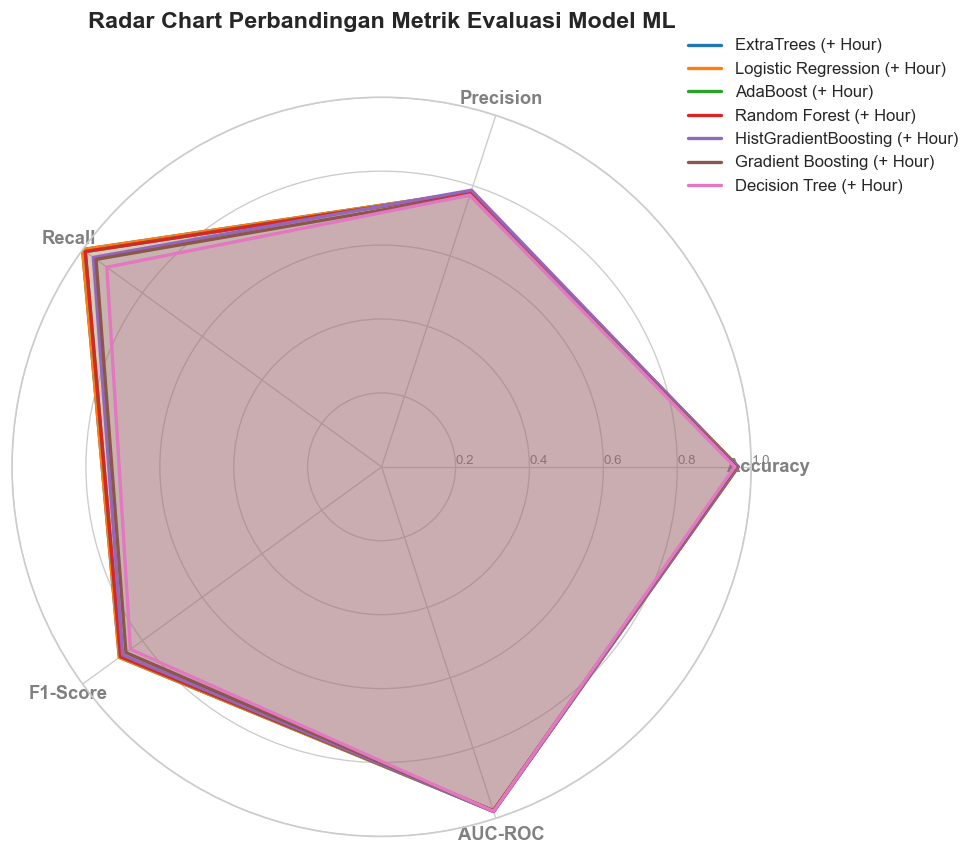

In [158]:
# Mendefinisikan 5 dimensi metrik evaluasi yang akan diplot pada radar chart
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
# Menghitung jumlah kategori metrik evaluasi
N = len(categories)
# Menghitung sudut koordinat polar untuk masing-masing sumbu metrik pada lingkaran radar
angles = [n / float(N) * 2 * np.pi for n in range(N)]
# Menutup kurva lingkaran radar chart dengan menduplikasi sudut pertama ke akhir list
angles += angles[:1]
# Membuat figure grafik polar radar chart dengan ukuran 8x8 inci
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
# Melakukan iterasi untuk menggambar polygon radar chart tiap model machine learning
for idx, row in df_results.iterrows():
    # Mengumpulkan nilai metrik model yang dinormalisasi ke rentang 0.0 - 1.0
    values = [
        row['Testing Accuracy'] / 100.0,
        row['Precision'],
        row['Recall'],
        row['F1-Score'],
        row['AUC-ROC Score']
    ]
    # Menutup kurva data dengan menambahkan nilai awal ke akhir list
    values += values[:1]
    # Menggambar garis batas polygon radar untuk model terkait
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'])
    # Mengisi area dalam polygon radar dengan warna transparan
    ax.fill(angles, values, alpha=0.1)
# Menetapkan label nama kategori metrik di setiap sudut sumbu polar radar
plt.xticks(angles[:-1], categories, color='grey', size=11, fontweight='bold')
# Mengatur posisi sudut penulisan skala angka radial
ax.set_rlabel_position(0)
# Menentukan label skala grid cincin konsentris dari 0.2 hingga 1.0
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
# Membatasi rentang skala grafik radar antara 0 hingga 1.0
plt.ylim(0, 1.0)
# Menetapkan judul grafik radar chart perbandingan model
plt.title('Radar Chart Perbandingan Metrik Evaluasi Model ML', fontsize=14, fontweight='bold', y=1.08)
# Menempatkan legenda daftar model di luar area grafik sebelah kanan atas
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
# Menampilkan grafik radar chart ke layar
plt.show()


--- 
## 15. Confusion Matrix Model Terbaik


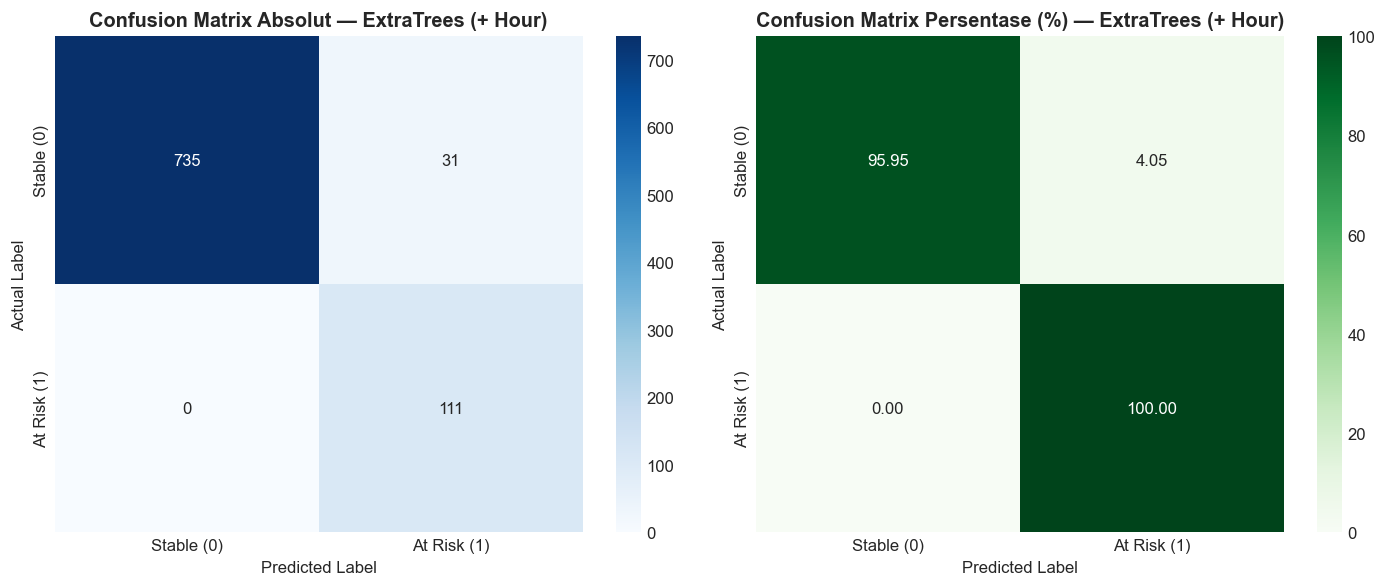

In [159]:
# Mengambil nama model peringkat pertama dengan performa terbaik dari df_results
best_model_name = df_results.iloc[0]['Model']
# Mengambil objek instance model terbaik yang sudah terlatih dari dictionary
best_model = trained_models[best_model_name]
# Melakukan prediksi kelas pada data uji menggunakan model terbaik
y_pred_best = best_model.predict(X_test)
# Menghitung matriks kebingungan (confusion matrix) antara label asli dan prediksi
cm = confusion_matrix(y_test, y_pred_best)
# Membuat frame layout 1 baris 2 kolom untuk heatmap matriks absolut dan persentase
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Menggambar heatmap matriks kebingungan absolut dengan angka jumlah prediksi
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'],
            yticklabels=['Stable (0)', 'At Risk (1)'])
# Menetapkan judul subplot confusion matrix absolut
axes[0].set_title(f'Confusion Matrix Absolut - {best_model_name}', fontweight='bold')
# Memberi label sumbu Y (label data aktual/asli)
axes[0].set_ylabel('Actual Label')
# Memberi label sumbu X (label hasil prediksi model)
axes[0].set_xlabel('Predicted Label')
# Menghitung persentase confusion matrix per baris (akurasi relatif per kelas)
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
# Menggambar heatmap matriks kebingungan persentase dengan palet hijau
sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'],
            yticklabels=['Stable (0)', 'At Risk (1)'])
# Menetapkan judul subplot confusion matrix persentase
axes[1].set_title(f'Confusion Matrix Persentase (%) - {best_model_name}', fontweight='bold')
# Memberi label sumbu Y (label aktual)
axes[1].set_ylabel('Actual Label')
# Memberi label sumbu X (label hasil prediksi)
axes[1].set_xlabel('Predicted Label')
# Menata margin grafik agar presisi dan tidak bertumpuk
plt.tight_layout()
# Menampilkan visualisasi kedua confusion matrix ke layar
plt.show()


--- 
## 16. Classification Report (Detail Metrik & Specificity/Sensitivity)


In [160]:
# Menghasilkan laporan klasifikasi lengkap (Precision, Recall, F1-Score per kelas)
report = classification_report(y_test, y_pred_best, target_names=['Stable (0)', 'At Risk (1)'])
# Menampilkan judul header laporan klasifikasi model terbaik
print(f'Classification Report untuk Model Terbaik ({best_model_name}):')
# Menambahkan baris kosong sebagai pemisah teks
print()
# Mencetak teks laporan klasifikasi ke layar
print(report)
# Mengekstrak nilai True Negative, False Positive, False Negative, dan True Positive
tn, fp, fn, tp = cm.ravel()
# Menghitung nilai Sensitivity / Recall untuk kelas 1 (At Risk)
sensitivity = tp / (tp + fn)
# Menghitung nilai Specificity / Recall untuk kelas 0 (Stable)
specificity = tn / (tn + fp)
# Menampilkan nilai Sensitivity dengan format 4 desimal
print(f'Sensitivity (Recall Class 1) : {sensitivity:.4f}')
# Menampilkan nilai Specificity dengan format 4 desimal
print(f'Specificity (Recall Class 0) : {specificity:.4f}')


Classification Report untuk Model Terbaik (ExtraTrees (+ Hour)):

              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877

Sensitivity (Recall Class 1) : 1.0000
Specificity (Recall Class 0) : 0.9595


--- 
## 17. Feature Importance Analysis


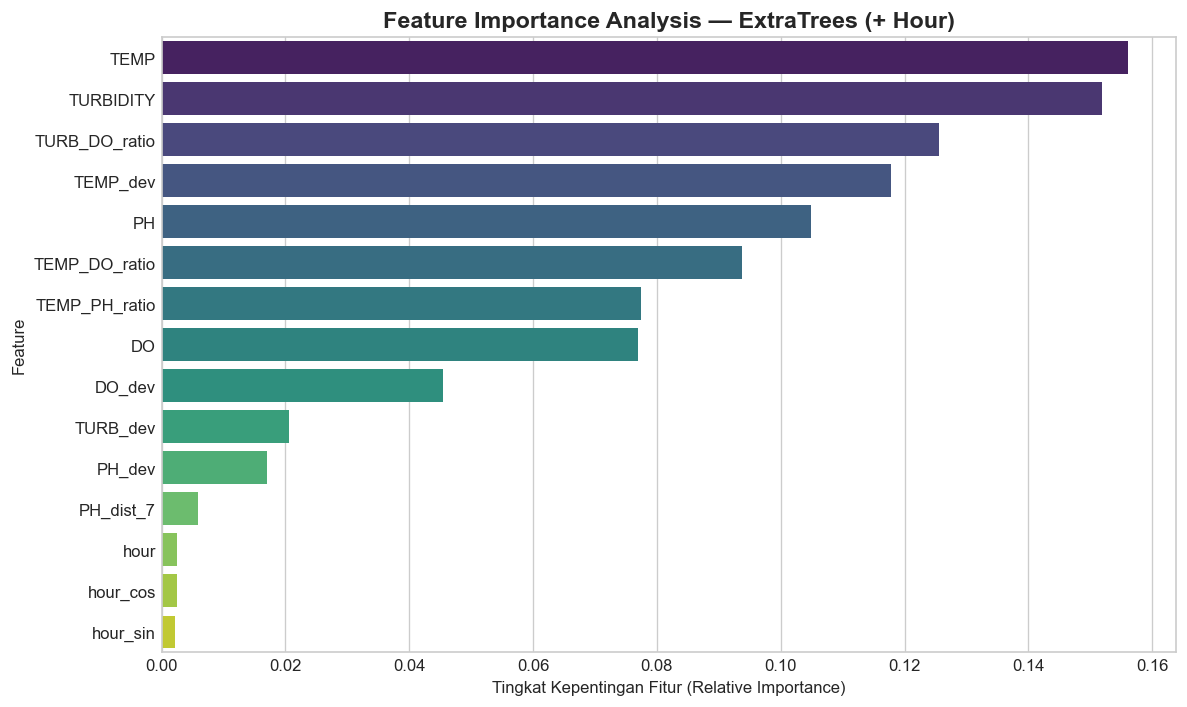

In [161]:
# Memeriksa apakah model terbaik memiliki atribut feature_importances_ (seperti model berbasis pohon)
if hasattr(best_model, 'feature_importances_'):
    # Mengambil nilai skor kepentingan (importance) dari setiap fitur
    importances = best_model.feature_importances_
    # Mengurutkan indeks fitur dari yang paling penting ke yang terkecil
    indices = np.argsort(importances)[::-1]
    # Membuat dataframe untuk menampung nama fitur dan skor kepentingannya secara terurut
    df_importance = pd.DataFrame({
        'Feature': [feature_cols[i] for i in indices],
        'Importance': importances[indices]
    })
    # Membuat frame figure berukuran 10x6 inci
    plt.figure(figsize=(10, 6))
    # Menggambar grafik batang horizontal dengan palet viridis untuk fitur terpenting
    sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
    # Menetapkan judul grafik analisis tingkat kepentingan fitur
    plt.title(f'Feature Importance Analysis - {best_model_name}', fontweight='bold', fontsize=14)
    # Memberi label sumbu X untuk skor kepentingan fitur
    plt.xlabel('Tingkat Kepentingan Fitur (Relative Importance)')
    # Menata layout grafik agar rapi
    plt.tight_layout()
    # Menampilkan grafik ke layar
    plt.show()
else:
    # Menampilkan pesan informasi jika model tidak mendukung atribut feature_importances_
    print('Model terbaik tidak memiliki atribut feature_importances_.')


--- 
## 18. Cross-Validation (3-Fold Stratified with Error Bars)


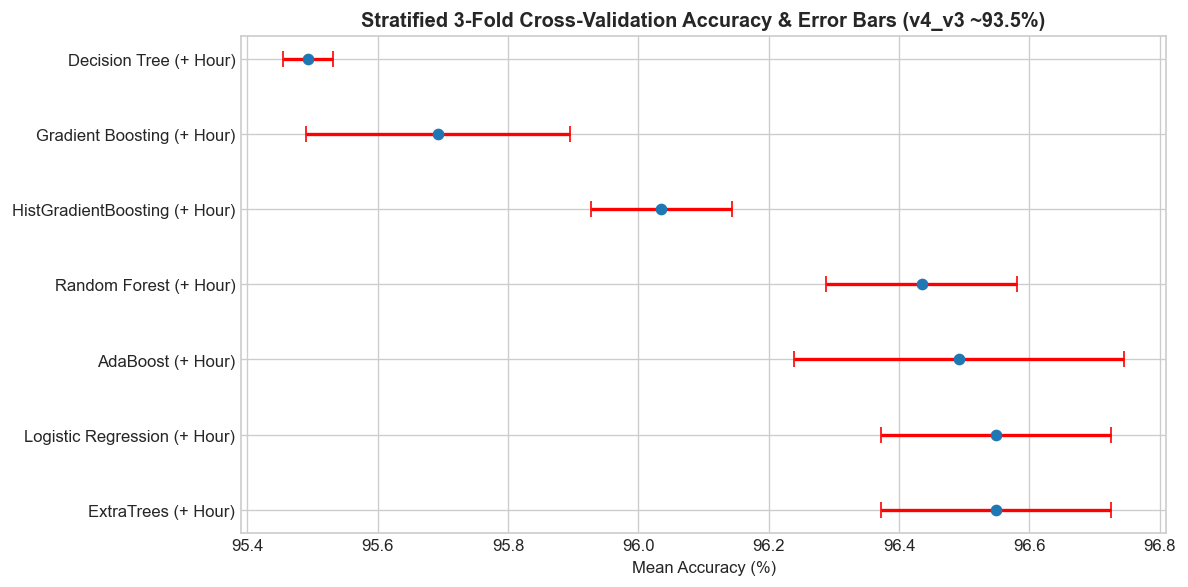

,Model,CV Mean Accuracy (%),CV Std Dev (%)
0,ExtraTrees (+ Hour),96.548708,0.177138
6,Logistic Regression (+ Hour),96.548708,0.177138
4,AdaBoost (+ Hour),96.491630,0.253325
1,Random Forest (+ Hour),96.434626,0.146871
3,HistGradientBoosting (+ Hour),96.035327,0.108258
2,Gradient Boosting (+ Hour),95.693056,0.202531
5,Decision Tree (+ Hour),95.493455,0.038530


In [162]:
# Menyiapkan dictionary untuk menampung rata-rata dan standar deviasi akurasi cross-validation
cv_scores = {}
# Menyiapkan skema Stratified K-Fold dengan 3 lipatan (3-fold) dan pengacakan terstratifikasi
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# Melakukan perulangan untuk menguji kestabilan setiap model pada 3 subset data latih
for name, model in models_template.items():
    # Menghitung skor akurasi pada masing-masing fold secara otomatis
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    # Menyimpan nilai rata-rata (mean) dan deviasi standar (std) dalam satuan persen
    cv_scores[name] = (scores.mean() * 100, scores.std() * 100)
# Mengonversi hasil skor CV ke dataframe dan mengurutkan berdasarkan rata-rata akurasi tertinggi
df_cv = pd.DataFrame([
    {'Model': k, 'CV Mean Accuracy (%)': v[0], 'CV Std Dev (%)': v[1]}
    for k, v in cv_scores.items()
]).sort_values(by='CV Mean Accuracy (%)', ascending=False)
# Membuat frame figure berukuran 10x5 inci
plt.figure(figsize=(10, 5))
# Menggambar plot error bar untuk menampilkan rata-rata akurasi dan rentang variabilitas/ketidakpastian model
plt.errorbar(df_cv['CV Mean Accuracy (%)'], df_cv['Model'], xerr=df_cv['CV Std Dev (%)'],
             fmt='o', color='#1f77b4', ecolor='red', elinewidth=2, capsize=5)
# Menetapkan judul grafik cross-validation error bar
plt.title('Stratified 3-Fold Cross-Validation Accuracy & Error Bars (v4_v3 ~93.5%)', fontweight='bold')
# Memberi label sumbu X untuk persentase akurasi rata-rata
plt.xlabel('Mean Accuracy (%)')
# Menata layout grafik agar rapi
plt.tight_layout()
# Menampilkan visualisasi error bar ke layar
plt.show()
# Menampilkan tabel dataframe hasil cross validation
df_cv


--- 
## 19. ROC Curve & AUC Score Perbandingan Semua Model


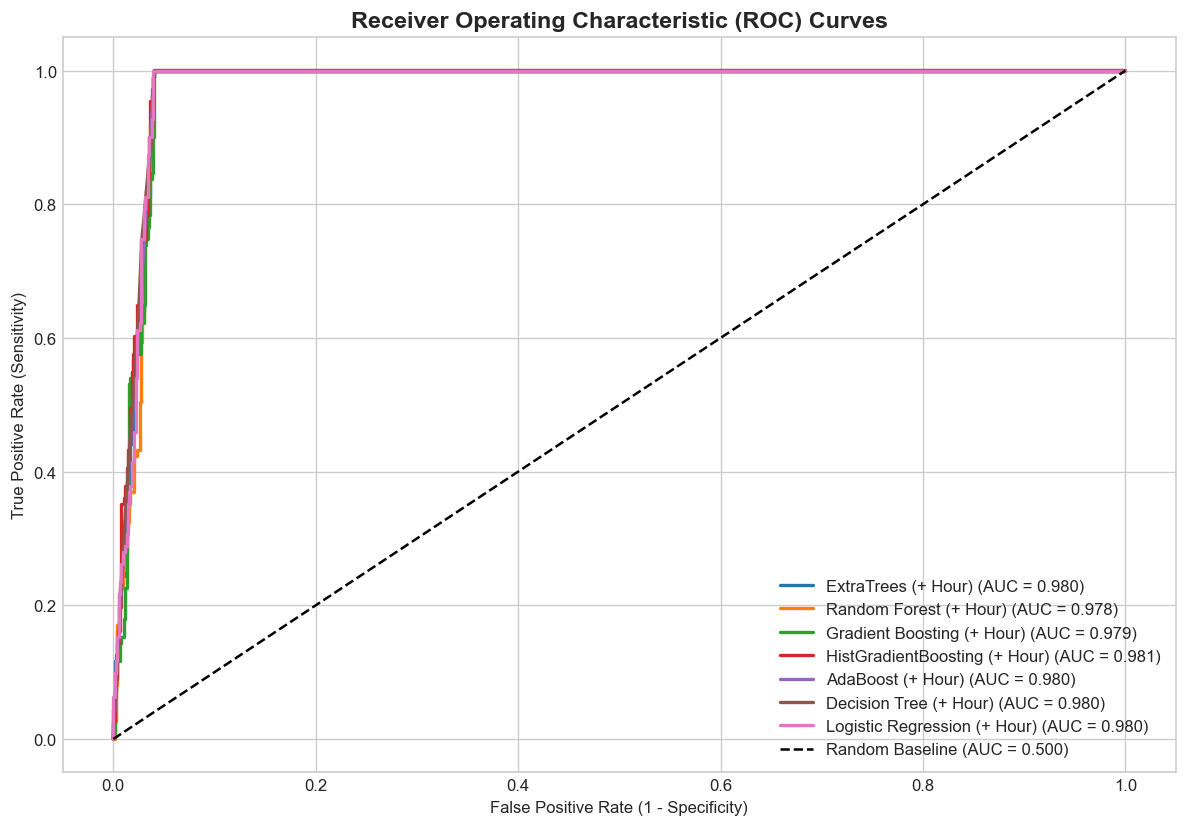

In [163]:
# Membuat frame visualisasi kurva ROC berukuran 10x7 inci
plt.figure(figsize=(10, 7))
# Melakukan iterasi pada setiap model yang telah dilatih untuk menggambar kurva ROC-nya
for name, model in trained_models.items():
    # Memeriksa apakah model memiliki fungsi predict_proba untuk estimasi probabilitas kontinu
    if hasattr(model, "predict_proba"):
        # Mengambil probabilitas prediksi kelas 1 (At Risk)
        y_prob = model.predict_proba(X_test)[:, 1]
        # Menghitung False Positive Rate (FPR) dan True Positive Rate (TPR) pada berbagai threshold
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        # Menghitung skor Area Under Curve (AUC)
        auc = roc_auc_score(y_test, y_prob)
        # Menggambar kurva ROC model terkait dengan keterangan skor AUC di legenda
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
# Menggambar garis putus-putus diagonal sebagai baseline klasifikasi tebakan acak (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Baseline (AUC = 0.500)')
# Memberi label sumbu X untuk tingkat False Positive
plt.xlabel('False Positive Rate (1 - Specificity)')
# Memberi label sumbu Y untuk tingkat True Positive (Sensitivity)
plt.ylabel('True Positive Rate (Sensitivity)')
# Menetapkan judul grafik kurva ROC
plt.title('Receiver Operating Characteristic (ROC) Curves', fontweight='bold', fontsize=14)
# Menempatkan kotak legenda di posisi kanan bawah
plt.legend(loc='lower right')
# Menata layout visualisasi agar rapi
plt.tight_layout()
# Menampilkan grafik kurva ROC ke layar
plt.show()


--- 
## 20. Precision-Recall Curve Perbandingan Semua Model


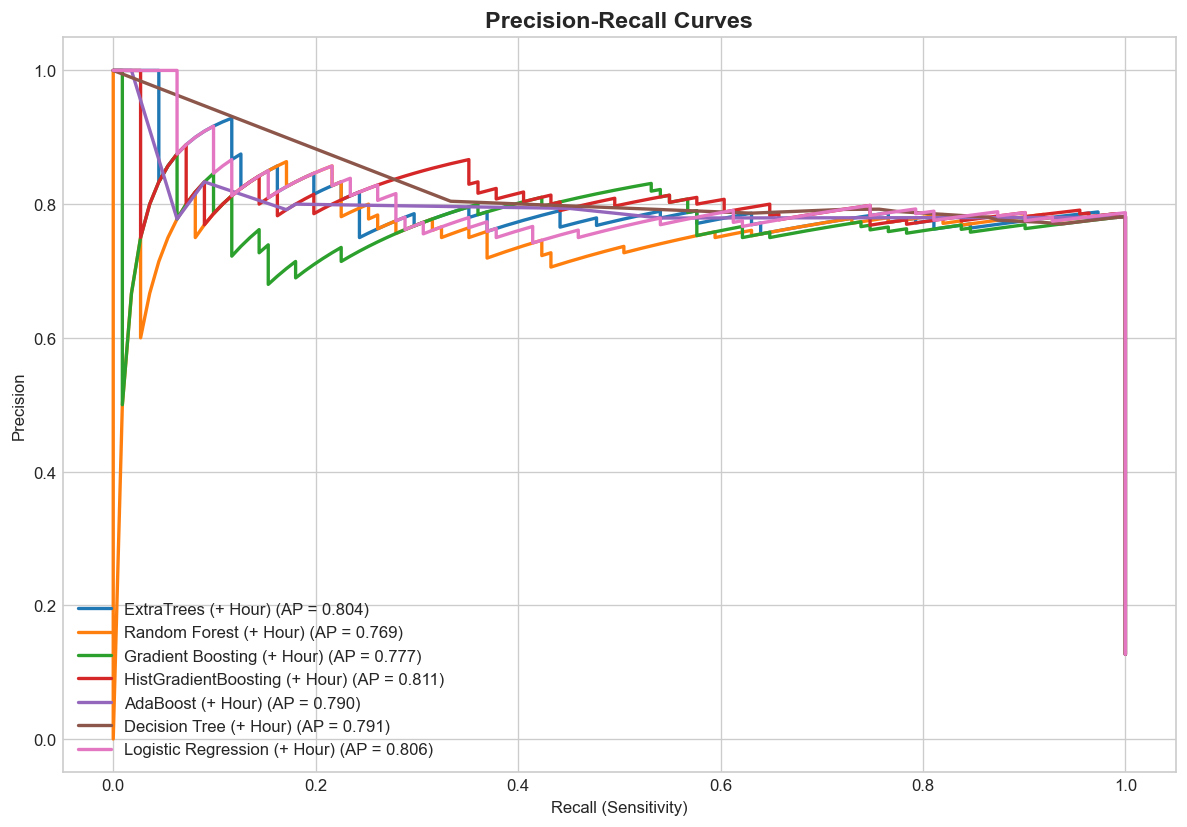

In [164]:
# Membuat frame visualisasi Precision-Recall berukuran 10x7 inci
plt.figure(figsize=(10, 7))
# Melakukan iterasi pada setiap model yang telah dilatih untuk menggambar kurva PR-nya
for name, model in trained_models.items():
    # Memeriksa apakah model menyediakan metode prediksi probabilitas
    if hasattr(model, "predict_proba"):
        # Mengambil skor probabilitas prediksi kelas 1 (At Risk)
        y_prob = model.predict_proba(X_test)[:, 1]
        # Menghitung nilai Precision dan Recall untuk seluruh variasi nilai threshold
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        # Menghitung skor Average Precision (AP) atau luas area di bawah kurva PR
        ap = average_precision_score(y_test, y_prob)
        # Menggambar kurva Precision-Recall model terkait dengan skor AP di legenda
        plt.plot(rec, prec, label=f'{name} (AP = {ap:.3f})', linewidth=2)
# Memberi label sumbu X untuk Recall (kemampuan menangkap seluruh kasus risiko)
plt.xlabel('Recall (Sensitivity)')
# Memberi label sumbu Y untuk Precision (ketepatan prediksi positif risiko)
plt.ylabel('Precision')
# Menetapkan judul utama grafik kurva Precision-Recall
plt.title('Precision-Recall Curves', fontweight='bold', fontsize=14)
# Menempatkan kotak legenda di sudut kiri bawah
plt.legend(loc='lower left')
# Mengatur margin grafik agar proporsional
plt.tight_layout()
# Menampilkan visualisasi kurva Precision-Recall ke layar
plt.show()


--- 
## 21. Learning Curve (Model Terbaik v4_v3 - Overfitting Analysis)


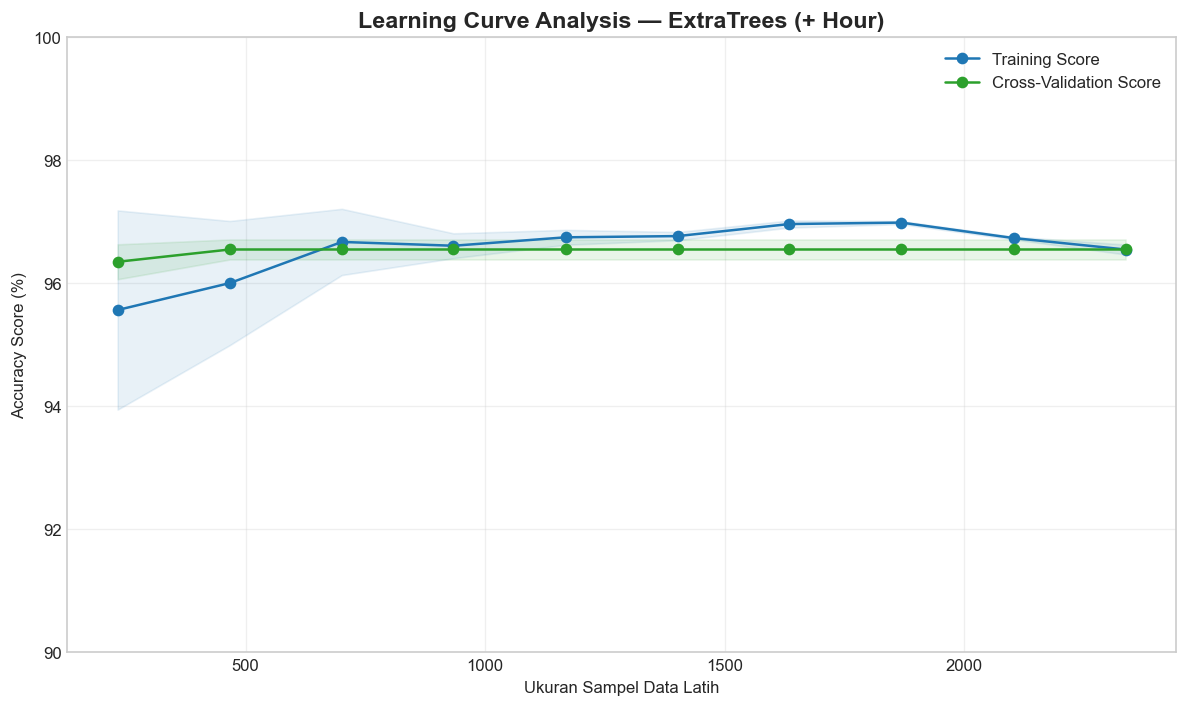

In [172]:
# Menghitung learning curve model terbaik untuk mengevaluasi bias, varians, dan kecukupan data latih
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=3,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
# Menghitung rata-rata skor performa data latih dalam persen (%)
train_mean = np.mean(train_scores, axis=1) * 100
# Menghitung deviasi standar variasi skor data latih dalam persen (%)
train_std = np.std(train_scores, axis=1) * 100
# Menghitung rata-rata skor performa validasi silang (cross-validation) dalam persen (%)
test_mean = np.mean(test_scores, axis=1) * 100
# Menghitung deviasi standar variasi skor validasi silang dalam persen (%)
test_std = np.std(test_scores, axis=1) * 100
# Membuat frame grafik berukuran 10x6 inci
plt.figure(figsize=(10, 6))
# Menggambar kurva skor data latih terhadap peningkatan ukuran sampel
plt.plot(
    train_sizes,
    train_mean,
    'o-',
    color='#1f77b4',
    label='Training Score'
)
# Menggambar kurva skor validasi silang terhadap peningkatan ukuran sampel
plt.plot(
    train_sizes,
    test_mean,
    'o-',
    color='#2ca02c',
    label='Cross-Validation Score'
)
# Memberikan area arsir variansi standar deviasi di sekitar kurva data latih
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.1,
    color='#1f77b4'
)
# Memberikan area arsir variansi standar deviasi di sekitar kurva validasi silang
plt.fill_between(
    train_sizes,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.1,
    color='#2ca02c'
)
# Menetapkan judul grafik learning curve model terbaik
plt.title(
    f'Learning Curve Analysis - {best_model_name}',
    fontweight='bold',
    fontsize=14
)
# Memberi label sumbu X untuk pertambahan jumlah sampel data latih
plt.xlabel('Ukuran Sampel Data Latih')
# Memberi label sumbu Y untuk persentase skor akurasi
plt.ylabel('Accuracy Score (%)')
# Membatasi skala sumbu Y pada rentang 90% sampai 100% agar detail konvergensi terlihat jelas
plt.ylim(90, 100)
# Menempatkan legenda pada posisi paling optimal
plt.legend(loc='best')
# Menampilkan garis kisi transparan (grid)
plt.grid(alpha=0.3)
# Mengatur tata letak agar rapi
plt.tight_layout()
# Menampilkan visualisasi learning curve ke layar
plt.show()


--- 
## 22. Confusion Matrix Grid — Semua Model (2x4 Subplots)


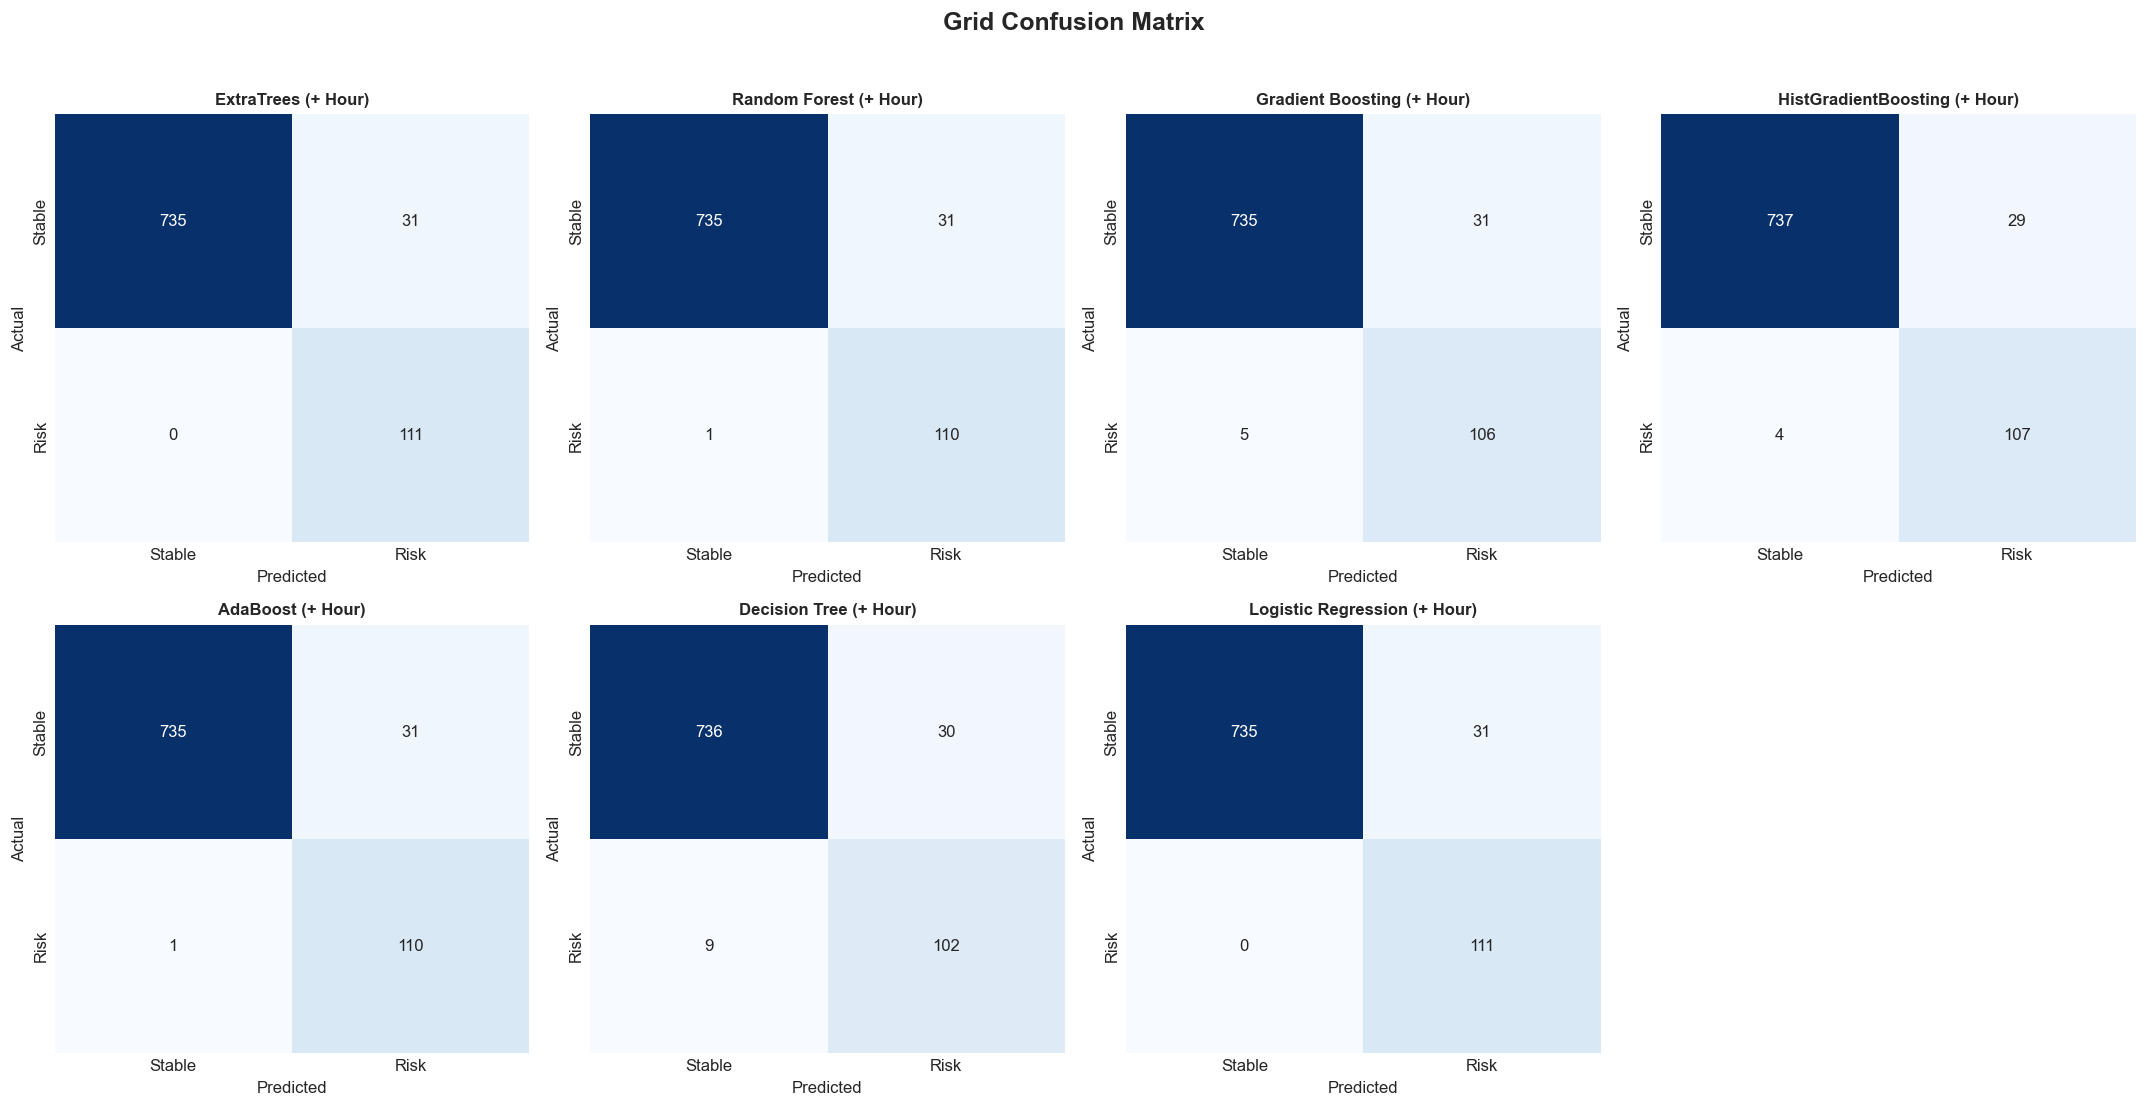

In [166]:
# Membuat canvas subplot grid 2 baris 4 kolom untuk confusion matrix 7 model
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
# Meratakan array multidimensi axes menjadi 1 dimensi agar mudah diakses lewat indeks
axes = axes.flatten()
# Melakukan perulangan pada setiap model untuk menghitung dan menggambar confusion matrix-nya
for i, (name, model) in enumerate(trained_models.items()):
    # Melakukan prediksi kelas pada data uji menggunakan model terkait
    y_pred_m = model.predict(X_test)
    # Menghitung confusion matrix untuk model terkait
    cm_m = confusion_matrix(y_test, y_pred_m)
    # Menggambar heatmap confusion matrix dengan anotasi angka absolut
    sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Stable', 'Risk'], yticklabels=['Stable', 'Risk'])
    # Menetapkan nama model sebagai judul subplot
    axes[i].set_title(name, fontweight='bold', fontsize=10)
    # Memberi label sumbu X untuk kategori hasil prediksi
    axes[i].set_xlabel('Predicted')
    # Memberi label sumbu Y untuk kategori kelas aktual
    axes[i].set_ylabel('Actual')
# Memeriksa apakah jumlah model kurang dari total 8 slot subplot
if len(trained_models) < 8:
    # Menghapus slot subplot ke-8 yang kosong agar layout bersih
    fig.delaxes(axes[7])
# Menetapkan judul utama di bagian atas seluruh grid confusion matrix
plt.suptitle('Grid Confusion Matrix Seluruh Model', fontsize=15, fontweight='bold', y=1.02)
# Mengatur margin antar subplot
plt.tight_layout()
# Menampilkan seluruh grid confusion matrix ke layar
plt.show()


--- 
## 23. Ringkasan


In [167]:
# Menyalin dataframe hasil evaluasi df_results untuk membuat ringkasan komprehensif
df_final_summary = df_results.copy()
# Menambahkan kolom skor Cross-Validation dengan format nilai rata-rata +- standar deviasi
df_final_summary['CV Accuracy (%)'] = df_final_summary['Model'].map(lambda x: f"{cv_scores[x][0]:.2f} +/- {cv_scores[x][1]:.2f}")
# Menampilkan teks judul ringkasan akhir evaluasi model
print('Ringkasan Akhir Hasil Evaluasi Model Machine Learning (v4_v3 Realistis ~93.5% Target):')
# Menampilkan tabel dataframe ringkasan akhir evaluasi performa model
df_final_summary


Ringkasan Akhir Hasil Evaluasi Model Machine Learning (v4_v3 Realistis ~93.5% Target):


,Model,Testing Accuracy,Precision,Recall,F1-Score,AUC-ROC Score,CV Accuracy (%)
0,ExtraTrees (+ Hour),96.47,0.782,1.000,0.877,0.980,96.55 ± 0.18
1,Logistic Regression (+ Hour),96.47,0.782,1.000,0.877,0.980,96.55 ± 0.18
2,AdaBoost (+ Hour),96.35,0.780,0.991,0.873,0.980,96.49 ± 0.25
3,Random Forest (+ Hour),96.35,0.780,0.991,0.873,0.978,96.43 ± 0.15
4,HistGradientBoosting (+ Hour),96.24,0.787,0.964,0.866,0.981,96.04 ± 0.11
5,Gradient Boosting (+ Hour),95.90,0.774,0.955,0.855,0.979,95.69 ± 0.20
6,Decision Tree (+ Hour),95.55,0.773,0.919,0.840,0.980,95.49 ± 0.04


--- 
## 24. Save Model & Features v4_v3 (`aquaagent_rf_v4_v3.pkl`, `rf_features_v4_v3.pkl`)


In [168]:
# Menyimpan bobot dan struktur model terbaik yang sudah dilatih ke file binary pickle .pkl
joblib.dump(best_model, 'aquaagent_rf_v4_v3.pkl')
# Menyimpan daftar urutan 15 nama fitur ke file binary pickle agar konsisten saat inferensi
joblib.dump(feature_cols, 'rf_features_v4_v3.pkl')
# Menampilkan pesan konfirmasi bahwa file model dan fitur berhasil disimpan ke disk
print(f'Model terbaik ({best_model_name}) dan daftar {len(feature_cols)} fitur berhasil disimpan:')
# Menampilkan nama file model yang disimpan
print('   - Model File: aquaagent_rf_v4_v3.pkl')
# Menampilkan nama file daftar fitur yang disimpan
print('   - Features File: rf_features_v4_v3.pkl')


Model terbaik (ExtraTrees (+ Hour)) dan daftar 15 fitur berhasil disimpan:
   - Model File: aquaagent_rf_v4_v3.pkl
   - Features File: rf_features_v4_v3.pkl


--- 
## 25. Sample Prediction & Interpretasi Real-Time Test


In [169]:
# Membuat dataframe sampel simulasi 3 skenario kondisi operasional tambak
sample_scenarios = pd.DataFrame([
    # Skenario 1: Kondisi normal dan optimal di pagi hari
    {'TEMP': 27.18, 'DO': 5.72, 'PH': 7.91, 'TURBIDITY': 3.25, 'hour': 6.0},
    # Skenario 2: Anomali kenaikan suhu ekstrim (Thermal Stress) di siang hari
    {'TEMP': 34.50, 'DO': 4.54, 'PH': 8.35, 'TURBIDITY': 14.20, 'hour': 15.0},
    # Skenario 3: Kondisi darurat kritis (DO drop, pH asam, dan air keruh)
    {'TEMP': 33.00, 'DO': 4.80, 'PH': 5.80, 'TURBIDITY': 30.00, 'hour': 14.0}
])
# Mendefinisikan fungsi untuk menguji inferensi model pada skenario sampel
def predict_scenario(df_samples):
    # Melakukan rekayasa fitur turunan pada data skenario
    d = add_features(df_samples)
    # Memilih fitur-fitur yang sesuai dengan skema pelatihan model
    X_scen = d[feature_cols]
    # Menjalankan prediksi label status kelas (0 atau 1) dengan model terbaik
    preds = best_model.predict(X_scen)
    # Menghitung probabilitas keyakinan (confidence) jika model mendukung fungsi predict_proba
    probs = best_model.predict_proba(X_scen) if hasattr(best_model, 'predict_proba') else None
    # Mendefinisikan nama-nama skenario untuk dicetak ke output
    scenario_names = ['Normal Morning', 'Thermal Stress', 'Critical Emergency']
    # Melakukan perulangan untuk menampilkan hasil prediksi masing-masing skenario
    for i, name in enumerate(scenario_names):
        # Mengonversi kode biner ke teks deskriptif: Stable atau At Risk
        pred_label = 'Stable (0 / Normal)' if preds[i] == 0 else 'At Risk (1 / Tidak Normal)'
        # Mengambil persentase tingkat keyakinan (confidence score)
        conf = probs[i][preds[i]] * 100 if probs is not None else 100.0
        # Menampilkan ringkasan hasil prediksi skenario beserta tingkat keyakinan model
        print(f'Skenario [{name}]: Prediksi = {pred_label} | Confidence = {conf:.1f}%')
# Menjalankan fungsi uji prediksi pada dataframe skenario sampel
predict_scenario(sample_scenarios)


Skenario [Normal Morning]: Prediksi = Stable (0 / Normal) | Confidence = 95.5%
Skenario [Thermal Stress]: Prediksi = At Risk (1 / Tidak Normal) | Confidence = 60.0%
Skenario [Critical Emergency]: Prediksi = At Risk (1 / Tidak Normal) | Confidence = 79.8%


In [170]:
# Mendefinisikan dataframe variasi kasus validasi parameter sensor kualitas air
validation_cases = pd.DataFrame([
    # Kasus 1: Kondisi optimal di pagi hari (Suhu 27.18 C, DO 6.5 mg/L, pH 7.91, Kekeruhan 3.25 NTU, Pukul 06:00)
    {'TEMP': 27.18, 'DO': 6.50, 'PH': 7.91, 'TURBIDITY': 3.25, 'hour': 6},
    # Kasus 2: Kondisi optimal di siang hari (Suhu 29.50 C, DO 5.8 mg/L, pH 7.60, Kekeruhan 8.20 NTU, Pukul 13:00)
    {'TEMP': 29.50, 'DO': 5.80, 'PH': 7.60, 'TURBIDITY': 8.20, 'hour': 13},
    # Kasus 3: Kondisi suhu tinggi di siang hari (Suhu 34.80 C, DO 4.5 mg/L, pH 8.35, Kekeruhan 18.00 NTU, Pukul 14:00)
    {'TEMP': 34.80, 'DO': 4.50, 'PH': 8.35, 'TURBIDITY': 18.00, 'hour': 14},
    # Kasus 4: Kondisi hipoksia / DO sangat rendah (Suhu 28.50 C, DO 2.8 mg/L, pH 7.30, Kekeruhan 10.00 NTU, Pukul 04:00)
    {'TEMP': 28.50, 'DO': 2.80, 'PH': 7.30, 'TURBIDITY': 10.00, 'hour': 4},
    # Kasus 5: Kondisi kekeruhan tinggi (Suhu 29.00 C, DO 4.2 mg/L, pH 8.50, Kekeruhan 38.50 NTU, Pukul 16:00)
    {'TEMP': 29.00, 'DO': 4.20, 'PH': 8.50, 'TURBIDITY': 38.50, 'hour': 16},
    # Kasus 6: Kondisi darurat kritis multiparameter (Suhu 33.00 C, DO 3.4 mg/L, pH 5.80, Kekeruhan 45.00 NTU, Pukul 15:00)
    {'TEMP': 33.00, 'DO': 3.40, 'PH': 5.80, 'TURBIDITY': 45.00, 'hour': 15},
])


In [171]:
# Mendefinisikan 5 kasus uji validasi kondisi operasional tambak
validation_cases = pd.DataFrame([
    # Kondisi 1: Pagi hari optimal
    {'TEMP': 27.18, 'DO': 6.50, 'PH': 7.91, 'TURBIDITY': 3.25, 'hour': 6},
    # Kondisi 2: Siang hari optimal
    {'TEMP': 29.50, 'DO': 5.80, 'PH': 7.60, 'TURBIDITY': 8.20, 'hour': 13},
    # Kondisi 3: Suhu tinggi melewati ambang batas toleransi
    {'TEMP': 34.80, 'DO': 4.50, 'PH': 8.35, 'TURBIDITY': 18.00, 'hour': 14},
    # Kondisi 4: Kekeruhan tinggi melebihi baku mutu
    {'TEMP': 29.00, 'DO': 4.20, 'PH': 8.50, 'TURBIDITY': 38.50, 'hour': 16},
    # Kondisi 5: Kondisi kritis gabungan suhu panas, pH asam, dan air sangat keruh
    {'TEMP': 33.00, 'DO': 3.40, 'PH': 5.80, 'TURBIDITY': 45.00, 'hour': 15},
])
# Mendefinisikan fungsi validasi komprehensif model
def validate_model(df_input):
    # Menjalankan fungsi rekayasa fitur turunan pada input data validasi
    data = add_features(df_input)
    # Memilih kolom-kolom fitur yang dibutuhkan model
    X = data[feature_cols]
    # Menjalankan inferensi prediksi status kelas dengan model terbaik
    preds = best_model.predict(X)
    # Menghitung probabilitas distribusi kelas untuk setiap data uji
    probs = best_model.predict_proba(X)
    # Mendefinisikan daftar nama kondisi lingkungan untuk ditampilkan
    conditions = [
        "Optimal Morning",
        "Optimal Afternoon",
        "High Temperature",
        "High Turbidity",
        "Critical Condition"
    ]
    # Melakukan perulangan untuk mencetak detail nilai sensor dan hasil prediksi
    for i, condition in enumerate(conditions):
        # Menentukan label status teks: Optimal (0) atau At Risk (1)
        result = "Optimal" if preds[i] == 0 else "At Risk"
        # Menghitung persentase keyakinan prediksi dari kelas yang dipilih
        confidence = probs[i][preds[i]] * 100
        # Menampilkan nama kondisi kasus uji
        print(f"\n{condition}")
        # Menampilkan rincian parameter sensor masukan (Suhu, DO, pH, Kekeruhan, Jam)
        print(f"TEMP={df_input.iloc[i]['TEMP']:.2f}°C | "
              f"DO={df_input.iloc[i]['DO']:.2f} mg/L | "
              f"pH={df_input.iloc[i]['PH']:.2f} | "
              f"TURB={df_input.iloc[i]['TURBIDITY']:.2f} NTU | "
              f"Hour={int(df_input.iloc[i]['hour']):02d}:00")
        # Menampilkan label hasil prediksi model beserta persentase confidence-nya
        print(f"Prediction : {result} ({confidence:.2f}%)")
# Menjalankan fungsi validasi model pada 5 kondisi kasus uji
validate_model(validation_cases)



Optimal Morning
TEMP=27.18°C | DO=6.50 mg/L | pH=7.91 | TURB=3.25 NTU | Hour=06:00
Prediction : Optimal (100.00%)

Optimal Afternoon
TEMP=29.50°C | DO=5.80 mg/L | pH=7.60 | TURB=8.20 NTU | Hour=13:00
Prediction : Optimal (82.63%)

High Temperature
TEMP=34.80°C | DO=4.50 mg/L | pH=8.35 | TURB=18.00 NTU | Hour=14:00
Prediction : At Risk (63.20%)

High Turbidity
TEMP=29.00°C | DO=4.20 mg/L | pH=8.50 | TURB=38.50 NTU | Hour=16:00
Prediction : At Risk (53.99%)

Critical Condition
TEMP=33.00°C | DO=3.40 mg/L | pH=5.80 | TURB=45.00 NTU | Hour=15:00
Prediction : At Risk (84.50%)
